# Import

In [225]:
import matplotlib as mpl
mpl.rcParams['font.family']='sans-serif'
mpl.rcParams['font.sans-serif']=['Arial']
mpl.rcParams['pdf.fonttype']=42
mpl.rcParams['text.usetex']=False

import os
import math
import json
import umap
import torch
import random
import pickle
import itertools
import numpy as np
import scanpy as sc
import pandas as pd
import seaborn as sns
import networkx as nx
from networkx.algorithms.community import louvain_communities

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.collections as mcollections

from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from matplotlib.patches import ConnectionPatch

from Bio.KEGG import REST
from collections import Counter
from adjustText import adjust_text
from scipy.spatial.distance import cdist
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics.pairwise import pairwise_distances

# Draw gene embeddings&statistics

## Functions

In [34]:
def plot_embeddings_drawing(all_embeddings,labels,connect_pairs=None):
    figsize_ratio=(1,1)
    figsize_x=0.48*(18.3/2.54) #figwidth=0.48*textwidth;textwidth=183mm;1inch=2.54cm
    figsize_y=figsize_ratio[1]*figsize_x/figsize_ratio[0]
    
    plt.figure(figsize=(figsize_x,figsize_y),constrained_layout=True)

    with plt.rc_context({'font.size':6}):
        ax=sns.scatterplot(x=all_embeddings[:,0],y=all_embeddings[:,1],
            hue=labels,s=6,alpha=0.3)
        ax.legend(loc='upper left',frameon=True,)

        if connect_pairs is not None:
            for i,j in connect_pairs:
                x_coords=[all_embeddings[i,0],all_embeddings[j,0]]
                y_coords=[all_embeddings[i,1],all_embeddings[j,1]]
                plt.plot(x_coords,y_coords,color='darkred',alpha=0.8,linewidth=0.7,linestyle='-')

        for collection in ax.collections:
            if isinstance(collection,mcollections.PathCollection):
                collection.set_rasterized(True)

        plt.title("Species gene embeddings",fontsize=6.5)
        plt.xlabel("t-SNE 1")
        plt.ylabel("t-SNE 2")
        plt.savefig('./save_drawing/gene_embedding_show&statistics/species_gene_embeddings.pdf',dpi=300,bbox_inches=None)
        plt.show()

In [129]:
def mean_distance_histogram_drawing(data_list,categories):
    means=[]
    sems=[]
    for data in data_list:
        mean=np.mean(data)
        sem=np.std(data,ddof=1)/np.sqrt(len(data))
        means.append(mean)
        sems.append(sem)
    x_pos=np.arange(len(categories))

    figsize_ratio=(7,5)
    figsize_x=0.48*(18.3/2.54) #figwidth=0.48*textwidth;textwidth=183mm;1inch=2.54cm
    figsize_y=figsize_ratio[1]*figsize_x/figsize_ratio[0]

    fig=plt.figure(figsize=(figsize_x,figsize_y),constrained_layout=True)

    with plt.rc_context({'font.size':6}):
        ax=plt.bar(x_pos,means,yerr=sems,
                width=0.35,capsize=3,
                color=sns.color_palette('colorblind',n_colors=len(means)),edgecolor='black',
                error_kw={'elinewidth':1,'capthick':1})
        plt.title('Mean embedding distance of gene pairs',fontsize=6.5)
        plt.xticks(x_pos,categories)
        size_pad=0.6
        plt.xlim(-size_pad,len(categories)-1+size_pad)

        plt.ylabel('Euclidean distance')
        fig.supxlabel('Mean ± s.e.m.',ha='center',fontsize=6.5,x=0.52)
        plt.savefig('./save_drawing/gene_embedding_show&statistics/mean_gene_embeddings_distances.pdf',bbox_inches=None)
        plt.show()

In [56]:
class SpeciesDataset(torch.utils.data.Dataset):
    def __init__(self,species_info):
        self.X=species_info['X']
        self.embedding_ref=species_info['embedding_ref']
        self.cell_names=species_info['cell_names']
        self.gene_names=species_info['gene_names']
        self.labels=species_info['labels']
        self.category_to_id=species_info['category_to_id']
        self.len=len(self.labels)

    def __getitem__(self,index):
        R_dict={}
        R_dict['cell_name']=self.cell_names[index]
        
        cell_X=self.X[index].coalesce()
        R_dict['location']=self.embedding_ref[cell_X.indices().squeeze(0)]
        R_dict['expression']=cell_X.values().unsqueeze(1)
        R_dict['label']=self.labels[index]
        return R_dict

    def __len__(self):
        return self.len

## Draw gene embeddings plot

In [57]:
mission_name='Frog_Zebrafish_2000hv_60000cell'
embedding_type='ESM1b'
all_species=['frog','zebrafish']

all_embeddings=torch.tensor([])
all_names=[]
labels=[]
species_index_range={}
current_index=0
for species in all_species:
    with open('./use_data/Save_DataSet/'+mission_name+'/'+embedding_type+'_'+species+'_train_set.pkl','rb') as f: 
        species_train_set=pickle.load(f) # train/test/val sets of one species have the same gene embeddings
        species_gene_embeddings=species_train_set.dataset.embedding_ref
        species_gene_names=species_train_set.dataset.gene_names
    all_embeddings=torch.cat((all_embeddings,species_gene_embeddings),dim=0)
    labels.extend([species]*len(species_gene_embeddings))
    all_names.extend(species_gene_names)
    species_index_range[species]=(current_index,current_index+len(species_gene_embeddings))
    current_index=current_index+len(species_gene_embeddings)

connect_pairs=[]
find_ortholog_dict={}
for i,gene_name in enumerate(all_names):
    if gene_name not in find_ortholog_dict:
        find_ortholog_dict[gene_name]=[]
    find_ortholog_dict[gene_name].append(i)

find_ortholog_dict={item:idx for item,idx in find_ortholog_dict.items() if len(idx)>1}
for ortholog_gene,index_list in find_ortholog_dict.items():
    connect_combs=list(itertools.combinations(index_list,2))
    connect_pairs.extend(connect_combs)

#drop the longest 10% edges
connect_pairs_distances=[]
for node1_idx,node2_idx in connect_pairs:
    distance=math.dist(all_embeddings[node1_idx],all_embeddings[node2_idx])
    connect_pairs_distances.append(distance)
keep_indices=np.argsort(connect_pairs_distances)[:int(0.9*len(connect_pairs))]
connect_pairs=np.array(connect_pairs)[keep_indices]

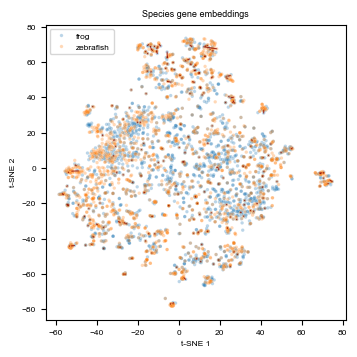

In [92]:
plot_embeddings_drawing(all_embeddings,labels,connect_pairs)

## Draw mean distance histogram

In [96]:
# Before running this cell, run the cell two cells above. (the preparation for plot_embeddings_drawing)
N=1000

cross_species_distances=[]
for i in range(N):
    species1,species2=random.sample(all_species,2)
    node1_idx=random.sample(range(species_index_range[species1][0],species_index_range[species1][1]),1)[0]
    node2_idx=random.sample(range(species_index_range[species2][0],species_index_range[species2][1]),1)[0]
    distance=math.dist(all_embeddings[node1_idx],all_embeddings[node2_idx])
    cross_species_distances.append(distance)

within_species_distances=[]
for species in all_species:
    for i in range(int(N/len(all_species))):
        node1_idx,node2_idx=random.sample(range(species_index_range[species][0],species_index_range[species][1]),2)
        distance=math.dist(all_embeddings[node1_idx],all_embeddings[node2_idx])
        within_species_distances.append(distance)

data_list=[connect_pairs_distances,cross_species_distances,within_species_distances]
categories=['ortholog','cross-species','within-species']

print(f'ortholog group: n={len(connect_pairs_distances)}')
print(f'cross-species group: n={N}')
print(f'within-species group: n={N}')

ortholog group: n=216
cross-species group: n=1000
within-species group: n=1000


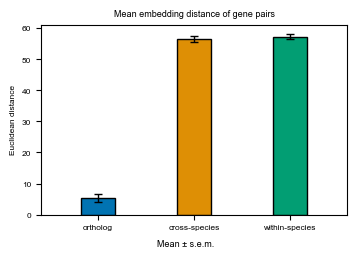

In [130]:
mean_distance_histogram_drawing(data_list,categories)

# Draw metrics by epoch

## Functions

In [2]:
def line_chart_drawing(x_list,y_lists,y_labels,title):
    plt.figure(figsize=(8,6))
    line_styles=['b-o','b--s','r-^','r--v']
    for i in range(len(y_labels)):
        plt.plot(x_list,y_lists[i],line_styles[i],label=y_labels[i],linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Metric value')
    plt.title(title)
    plt.legend()

    #plt.grid(True,alpha=0.3)
    plt.xticks(x_list)
    plt.yticks(np.linspace(0,1,11))
    plt.tight_layout()
    plt.savefig(f'./save_drawing/metrics_by_epoch/{title}.pdf',bbox_inches='tight')
    plt.show()

In [3]:
def draw_metrics_by_epoch(metrics_by_epoch_file_path,title):
    with open(metrics_by_epoch_file_path,'r') as f:
        dict=json.load(f)
    
    epochs=[]
    frog_accuracy,frog_f1_score=[],[]
    zebrafish_accuracy,zebrafish_f1_score=[],[]
    for key in dict:
        epochs.append(key)
        frog_accuracy.append(dict[key]['accuracy']['frog'])
        frog_f1_score.append(dict[key]['f1_score']['frog'])
        zebrafish_accuracy.append(dict[key]['accuracy']['zebrafish'])
        zebrafish_f1_score.append(dict[key]['f1_score']['zebrafish'])
    
    y_lists=[frog_accuracy,frog_f1_score,zebrafish_accuracy,zebrafish_f1_score]
    y_labels=['frog_accuracy','frog_f1_score','zebrafish_accuracy','zebrafish_f1_score']
    
    line_chart_drawing(epochs,y_lists,y_labels,title)

## Draw

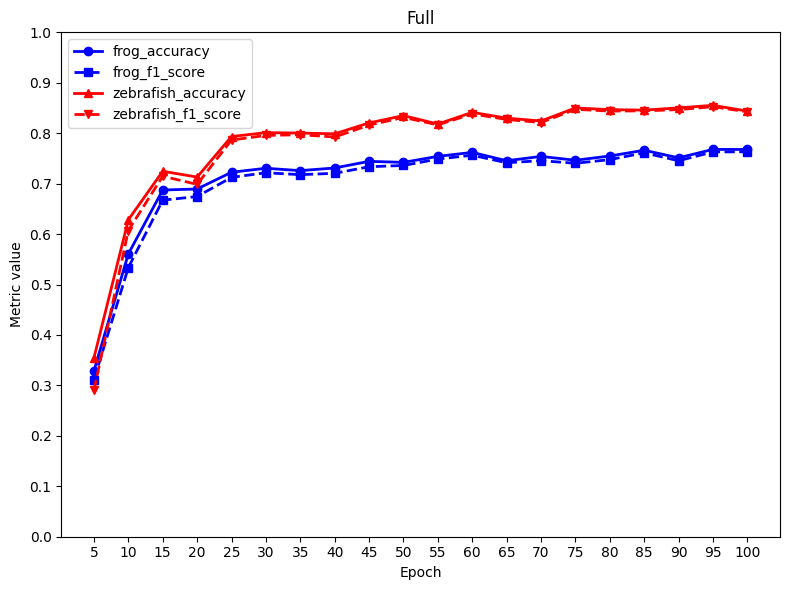

In [4]:
draw_metrics_by_epoch('./use_data/Save_for_Drawing/metrics_by_epoch.json',title='Full')

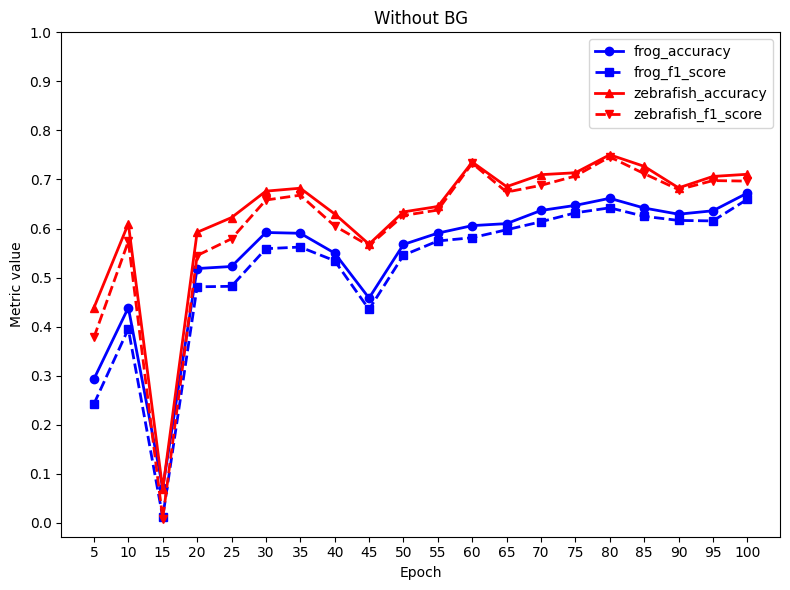

In [5]:
draw_metrics_by_epoch('./use_data/Save_for_Drawing/metrics_by_epoch_ablate_V1.json',title='Without BG')

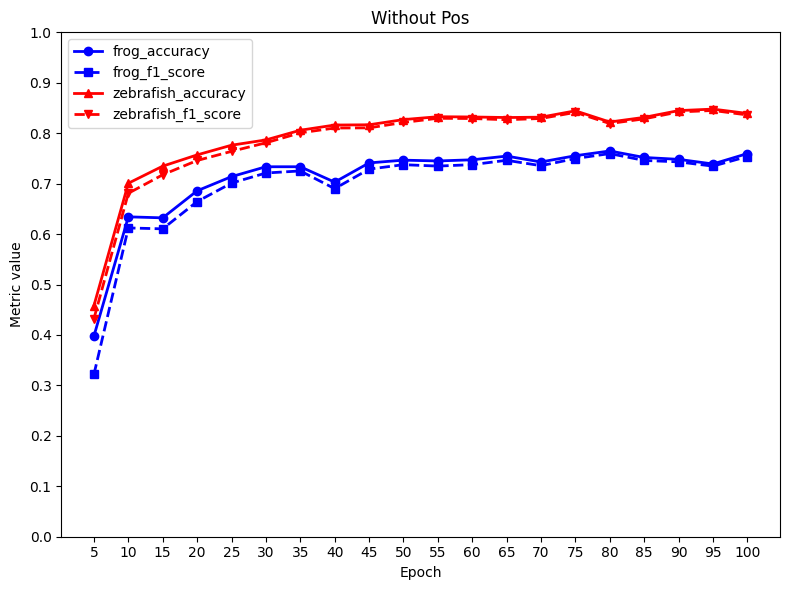

In [6]:
draw_metrics_by_epoch('./use_data/Save_for_Drawing/metrics_by_epoch_ablate_V2.json',title='Without Pos')

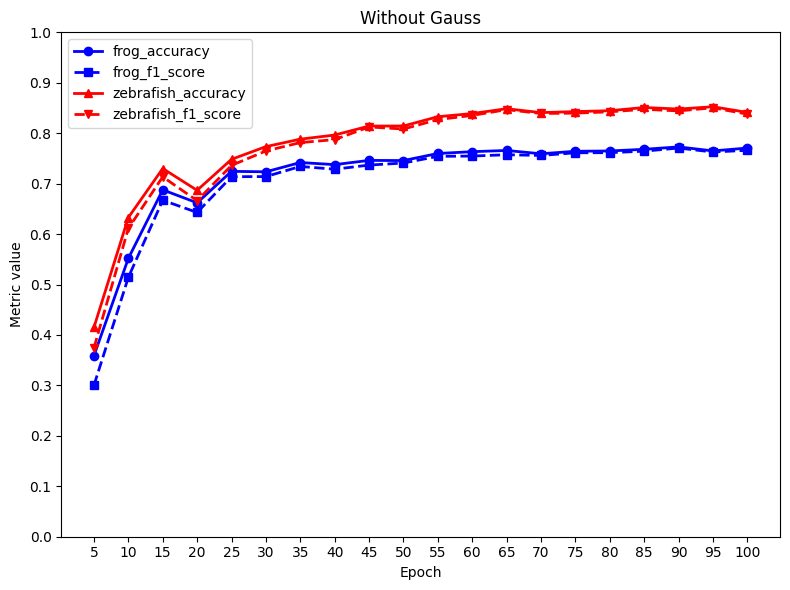

In [7]:
draw_metrics_by_epoch('./use_data/Save_for_Drawing/metrics_by_epoch_ablate_V3.json',title='Without Gauss')

## Side-by-side line charts with shared legend (for figures)

### Functions

In [16]:
def _draw_metrics_by_epoch(metrics_by_epoch_file_path,ax,title,i):
    with open(metrics_by_epoch_file_path,'r') as f:
        dict=json.load(f)
    
    epochs=[]
    frog_accuracy,frog_f1_score=[],[]
    zebrafish_accuracy,zebrafish_f1_score=[],[]
    for key in dict:
        epochs.append(key)
        frog_accuracy.append(dict[key]['accuracy']['frog'])
        frog_f1_score.append(dict[key]['f1_score']['frog'])
        zebrafish_accuracy.append(dict[key]['accuracy']['zebrafish'])
        zebrafish_f1_score.append(dict[key]['f1_score']['zebrafish'])
    
    y_lists=[frog_accuracy,frog_f1_score,zebrafish_accuracy,zebrafish_f1_score]
    y_labels=['frog_accuracy','frog_f1_score','zebrafish_accuracy','zebrafish_f1_score']

    line_styles=['b-o','b--s','r-^','r--v']
    for j in range(len(y_labels)):
        ax.plot(epochs,y_lists[j],line_styles[j],label=y_labels[j],linewidth=0.5,markersize=2)
    if i==0:
        ax.set_xlabel('Epoch',fontsize=6)
        ax.set_ylabel('Metric value',fontsize=6)
    else:
        ax.set_xlabel('')
        ax.set_ylabel('')
    ax.set_title(title,fontsize=6.5)

    ax.set_xticks(epochs)
    ax.set_yticks(np.linspace(0,1,11))
    ax.tick_params(axis='both',labelsize=5.5)

In [17]:
def multi_line_chart_drawing(metrics_by_epoch_file_list,titles,save_name=None):
    n=len(metrics_by_epoch_file_list)
    figsize_ratio=(7*n+n-1,6)
    figsize_x=0.85*(18.3/2.54) #figwidth=0.85*textwidth;textwidth=183mm;1inch=2.54cm
    figsize_y=figsize_ratio[1]*figsize_x/figsize_ratio[0]
    
    fig,axes=plt.subplots(1,n,figsize=(figsize_x,figsize_y),squeeze=False,gridspec_kw={'left':0.04,'right':0.98,'bottom':0.25,'wspace':0.12})
    axes=axes.flatten()
    with plt.rc_context({'font.size':6}):
        for i,(file_name,ax) in enumerate(zip(metrics_by_epoch_file_list,axes)):
            _draw_metrics_by_epoch(file_name,ax,titles[i],i)
    
        handles,labels=axes[0].get_legend_handles_labels()
        if handles:
            additional_args={}
            fig.legend(handles,labels,loc='upper center',bbox_to_anchor=(0.5,0.15),frameon=False,ncols=2)

        if save_name is not None:
            plt.savefig(f'./save_drawing/metrics_by_epoch/{save_name}.pdf',bbox_inches=None)
        plt.show()

### Draw

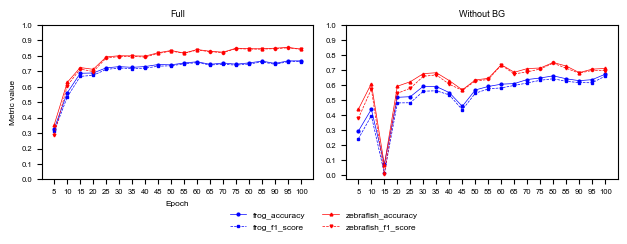

In [19]:
files=['./use_data/Save_for_Drawing/metrics_by_epoch.json','./use_data/Save_for_Drawing/metrics_by_epoch_ablate_V1.json']
titles=['Full','Without BG']
multi_line_chart_drawing(files,titles,'figs6')

# Draw cell embeddings

## Functions

In [279]:
def default_umap_drawing(adata_file_name,unified_color_dict=None,save_name=None):
    embedding_adata=sc.read(f'./use_data/Save_for_Drawing/{adata_file_name}')
    mask=embedding_adata.obs.query("not cell_type.str.endswith('_subcenter')").index
    embedding_adata_filtered=embedding_adata[mask,:].copy()
    adata=embedding_adata_filtered
    sc.pp.pca(adata) #also necessary for umap
    sc.pp.neighbors(adata,random_state=0)
    sc.tl.umap(adata,random_state=0)

    fig,ax=plt.subplots(figsize=(6,6))
    sc.pl.umap(adata,color="species",title="Species",ax=ax,show=False)
    if save_name is not None:
        plt.savefig(f'./save_drawing/cell_embedding_show/{save_name}_species.pdf',bbox_inches='tight')
    plt.show()

    fig2,ax2=plt.subplots(figsize=(6,6))
    sc.pl.umap(adata,color="cell_type",palette=unified_color_dict,title="Cell Type",ax=ax2,show=False)
    if save_name is not None:
        plt.savefig(f'./save_drawing/cell_embedding_show/{save_name}_celltypes.pdf',bbox_inches='tight')
    plt.show()

In [280]:
#save file only when there is prefix
def draw_target_celltypes(adata_file_name,targets,legend_loc='lower right',prefix=None):
    embedding_adata=sc.read(f'./use_data/Save_for_Drawing/{adata_file_name}')
    mask=embedding_adata.obs.query("not cell_type.str.endswith('_subcenter')").index
    embedding_adata_filtered=embedding_adata[mask,:].copy()
    adata=embedding_adata_filtered
    sc.pp.pca(adata) #also necessary for umap
    sc.pp.neighbors(adata,random_state=0)
    sc.tl.umap(adata,random_state=0)

    captions=[]
    all_species=sorted(adata.obs['species'].unique())
    adata.obs['_cell_type']='Other'
    for target in targets:
        for species in all_species:
            condition=(adata.obs['cell_type']==target)&(adata.obs['species']==species)
            adata.obs.loc[condition,'_cell_type']=target+'_'+species
            captions.append(target+'_'+species)
    if len(captions)<=2:
        palette=sns.color_palette("tab10",len(captions))
    elif len(captions)<=12:
        palette=sns.color_palette("Paired",len(captions))
    else:
        palette=sns.color_palette("tab20",len(captions))
    color_dict=dict(zip(captions,palette))
    color_dict['Other']='darkgrey'
    adata.obs['_cell_type']=pd.Categorical(adata.obs['_cell_type'],categories=color_dict.keys(),ordered=True) # to order the caption

    mask_others=adata.obs['_cell_type']=='Other'
    idx_others=np.where(mask_others)[0]
    idx_non_others=np.where(~mask_others)[0]
    new_order=np.concatenate([idx_others,idx_non_others])
    _adata=adata[new_order,:].copy()

    figsize_ratio=(1,1)
    figsize_x=0.48*(18.3/2.54) #figwidth=0.48*textwidth;textwidth=183mm;1inch=2.54cm
    figsize_y=figsize_ratio[1]*figsize_x/figsize_ratio[0]

    fig,ax=plt.subplots(figsize=(figsize_x,figsize_y),constrained_layout=True)

    with plt.rc_context({'axes.titlesize':6.5,'legend.fontsize':5.1,}):
        sc.pl.umap(_adata,color="_cell_type",palette=color_dict,alpha=0.5,size=8,edgecolor='none',title="Cell Type",ax=ax,legend_loc=legend_loc,show=False)
        
    ax.set_box_aspect(1)
    ax.set_xlabel('UMAP1',fontsize=5.5)
    ax.set_ylabel('UMAP2',fontsize=5.5)
    legend=ax.get_legend()
    if legend is not None:
        frame=legend.get_frame()
        frame.set_alpha(0.5)

    for collection in ax.collections:
        if isinstance(collection,mcollections.PathCollection):
            collection.set_rasterized(True)

    if prefix is not None:
        target=targets[0].replace('/','-') # express 'or' without being interpreted as a file separator
        if len(targets)>1:
            target=target+'_mixed'
            #target=target+f'_mixed_{str(int(time.time()))}' # if need more version of mixed drawing
        plt.savefig(f'./save_drawing/cell_embedding_show/{prefix}_{target}_embedding_show.pdf',bbox_inches=None,dpi=300)
    plt.show()

In [281]:
def draw_all_common_celltypes_of_frog_and_zebrafish(adata_file_name,prefix=None):
    df=pd.read_csv(f'./data/processed_data/frog_zebrafish_cell_type_map.csv')
    same_type_rows=df[df['frog_cell_type']==df['zebrafish_cell_type']]
    same_types=same_type_rows['frog_cell_type']
    print(f'total {len(same_types)} matched cell types')
    for cell_type in same_types:
        targets=[cell_type]
        draw_target_celltypes(adata_file_name,targets,prefix)

## Unify the cell_type color palette

In [2]:
to_unify_color_file_names=['frog_zebrafish_95_epoch_embedding.h5ad','s_arcface_model_75_fixed_25_epoch_pretrain_embedding.h5ad',\
       's_triplet_model_100_fixed_25_epoch_pretrain_embedding.h5ad']

all_cell_types=set()
for adata_file_name in to_unify_color_file_names:
    embedding_adata=sc.read(f'./use_data/Save_for_Drawing/{adata_file_name}')
    S=set(embedding_adata.obs['cell_type'])
    S={x for x in S if not x.endswith('_subcenter')}
    all_cell_types.update(S)
all_cell_types_sorted=sorted(all_cell_types)

default_palette =sc.pl.palettes.default_102
unified_color_dict={ct:default_palette[i%len(default_palette)]
              for i,ct in enumerate(all_cell_types_sorted)}

## Draw cell embeddings of GECross

In [168]:
#default_umap_drawing('frog_zebrafish_95_epoch_embedding.h5ad',unified_color_dict,'GECross_embedding_show')

In [150]:
#draw_all_common_celltypes_of_frog_and_zebrafish('frog_zebrafish_95_epoch_embedding.h5ad','GECross')

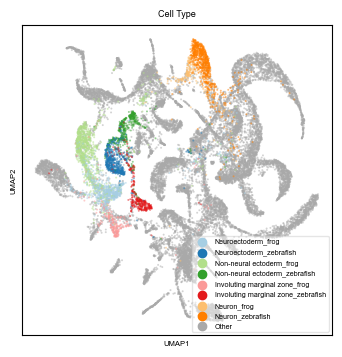

In [144]:
draw_target_celltypes('frog_zebrafish_95_epoch_embedding.h5ad',['Neuroectoderm','Non-neural ectoderm','Involuting marginal zone','Neuron'],\
                      'lower right','GECross')

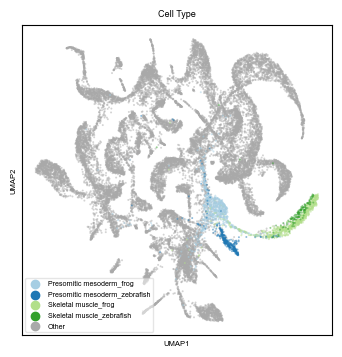

In [145]:
draw_target_celltypes('frog_zebrafish_95_epoch_embedding.h5ad',['Presomitic mesoderm','Skeletal muscle'],\
                      'lower left','GECross')

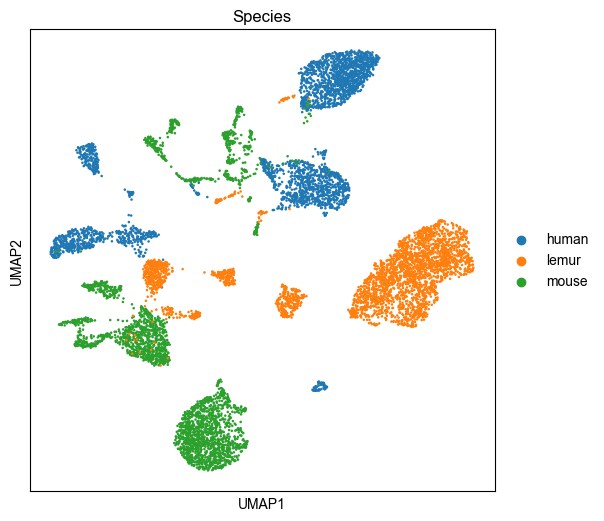

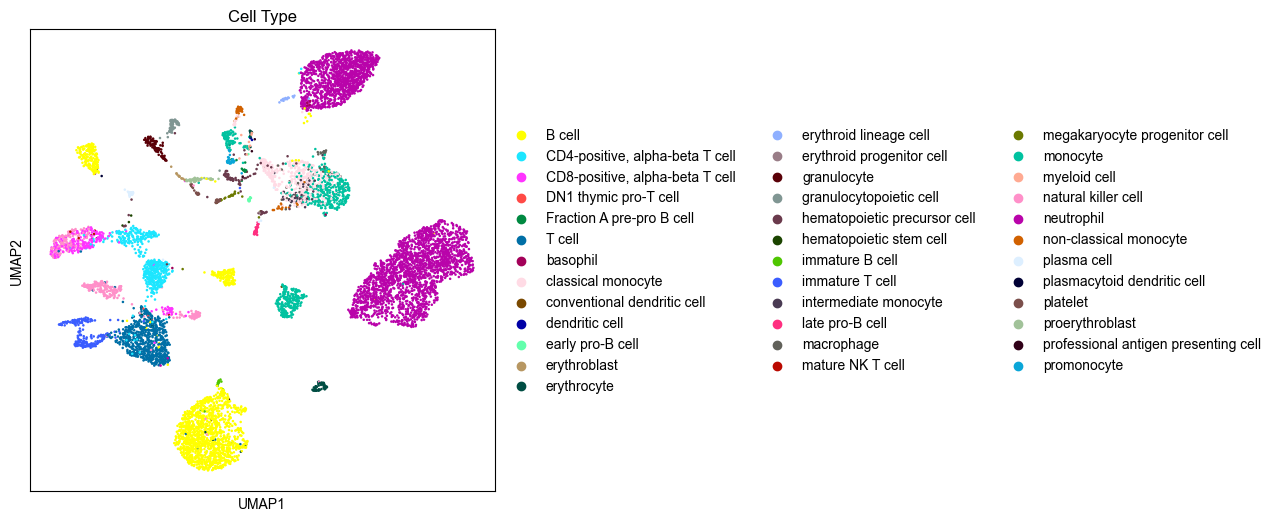

In [191]:
# Draw human & mouse & lemur blood
default_umap_drawing('human_mouse_lemur_95_epoch_embedding.h5ad',unified_color_dict=None,save_name='plus_GECross_embedding_show')

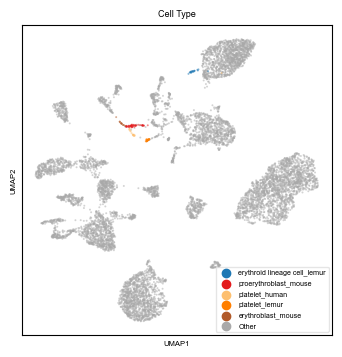

In [282]:
draw_target_celltypes('human_mouse_lemur_95_epoch_embedding.h5ad',
                      ['erythroid lineage cell','proerythroblast','platelet','erythroblast'],\
                      'lower right','HML')

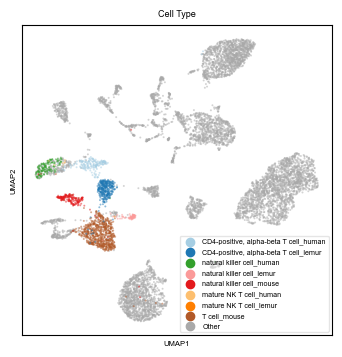

In [285]:
draw_target_celltypes('human_mouse_lemur_95_epoch_embedding.h5ad',
                      ['CD4-positive, alpha-beta T cell','natural killer cell','mature NK T cell','T cell'],\
                      'lower right','HML')

## Side-by-side UMAPs with shared legend (for figures)

### Functions

In [5]:
def _prepare_umap(adata_file_name):
    embedding_adata=sc.read(f'./use_data/Save_for_Drawing/{adata_file_name}')
    mask=embedding_adata.obs.query("not cell_type.str.endswith('_subcenter')").index
    embedding_adata_filtered=embedding_adata[mask,:].copy()
    adata=embedding_adata_filtered
    sc.pp.pca(adata) #also necessary for umap
    sc.pp.neighbors(adata,random_state=0)
    sc.tl.umap(adata,random_state=0)
    return adata

In [6]:
def _draw_single_umap(adata,ax,title,i,mode='species',mode_args={}):
    if mode=='species':
        with plt.rc_context({'axes.titlesize':6.5,}):
            sc.pl.umap(adata,color="species",title=f"{title}",size=1,ax=ax,show=False)
    elif mode=='cell_type':
        with plt.rc_context({'axes.titlesize':6.5,}):
            sc.pl.umap(adata,color="cell_type",palette=mode_args['unified_color_dict'],size=1,title=f"{title}",ax=ax,show=False)
    elif mode=='target_celltypes':
        captions=[]
        all_species=sorted(adata.obs['species'].unique())
        adata.obs['_cell_type']='Other'
        for target in mode_args['targets']:
            for species in all_species:
                condition=(adata.obs['cell_type']==target)&(adata.obs['species']==species)
                adata.obs.loc[condition,'_cell_type']=target+'_'+species
                captions.append(target+'_'+species)
        if len(captions)<=2:
            palette=sns.color_palette("tab10",len(captions))
        else:
            palette=sns.color_palette("Paired",len(captions))
        color_dict=dict(zip(captions,palette))
        color_dict['Other']='darkgrey'
        adata.obs['_cell_type']=pd.Categorical(adata.obs['_cell_type'],categories=color_dict.keys(),ordered=True) # to order the caption
    
        mask_others=adata.obs['_cell_type']=='Other'
        idx_others=np.where(mask_others)[0]
        idx_non_others=np.where(~mask_others)[0]
        new_order=np.concatenate([idx_others,idx_non_others])
        _adata=adata[new_order,:].copy()

        with plt.rc_context({'axes.titlesize':6.5,}):
            sc.pl.umap(_adata,color="_cell_type",palette=color_dict,alpha=0.5,size=5,title=f"{title}",ax=ax,show=False)

    ax.set_box_aspect(1)
    if i==0:
        ax.set_xlabel('UMAP1',fontsize=5.5)
        ax.set_ylabel('UMAP2',fontsize=5.5)
    else:
        ax.set_xlabel('')
        ax.set_ylabel('')

    for collection in ax.collections:
        if isinstance(collection,mcollections.PathCollection):
            collection.set_rasterized(True)
    
    legend=ax.get_legend()
    if legend is not None:
        legend.remove()

In [7]:
def multi_umaps_drawing(adata_file_list,titles,mode='species',mode_args={},save_name=None):
    n=len(adata_file_list)
    figsize_ratio=(1*n,1)
    figsize_x=0.85*(18.3/2.54) #figwidth=0.85*textwidth;textwidth=183mm;1inch=2.54cm
    figsize_y=figsize_ratio[1]*figsize_x/figsize_ratio[0]

    fig,axes=plt.subplots(1,n,figsize=(figsize_x,figsize_y),squeeze=False)
    axes=axes.flatten()
    for i,(adata_file_name,ax) in enumerate(zip(adata_file_list,axes)):
        adata=_prepare_umap(adata_file_name)
        _draw_single_umap(adata,ax,titles[i],i,mode,mode_args)

    mode_to_legend_title_dict={'species':'Species','cell_type':'Cell Type','target_celltypes':'Cell Type'}
    handles,labels=axes[0].get_legend_handles_labels()
    if handles:
        additional_args={'fontsize':5.1,'title_fontsize':6,'markerscale':0.3,'labelspacing':0.08,'columnspacing':0.03,'handletextpad':0.03,'borderpad':0.05}
        ncol=max(1,int(np.ceil(len(labels)/10))) # maximum 10 items per col
        fig.legend(handles,labels,loc='upper center',bbox_to_anchor=(0.5,0.12),ncol=ncol,
                   title=mode_to_legend_title_dict[mode],frameon=False,**additional_args)

    if save_name is not None:
        plt.savefig(f'./save_drawing/cell_embedding_show/{save_name}.pdf',bbox_inches='tight',dpi=300)
    plt.show()

### Draw

In [21]:
adata_file_list=['frog_zebrafish_95_epoch_embedding.h5ad','s_arcface_model_75_fixed_25_epoch_pretrain_embedding.h5ad','s_triplet_model_100_fixed_25_epoch_pretrain_embedding.h5ad']
titles=['GECross','SATURN-ArcFace','SATURN-triplet']

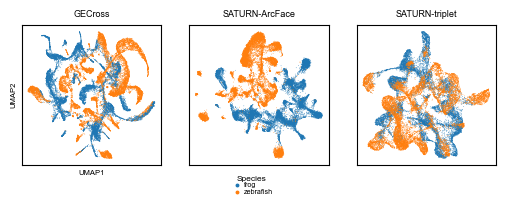

In [161]:
multi_umaps_drawing(adata_file_list,titles,'species',{},'fig2a_1')

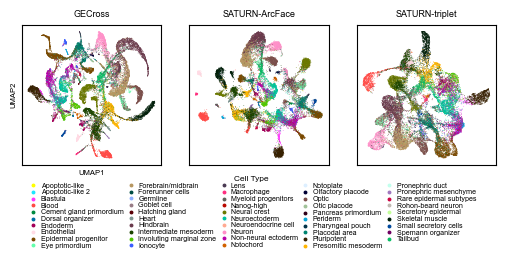

In [162]:
mode_args={'unified_color_dict':unified_color_dict}
multi_umaps_drawing(adata_file_list,titles,'cell_type',mode_args,'fig2a_2')
#unified_color_dict can be got from earlier block

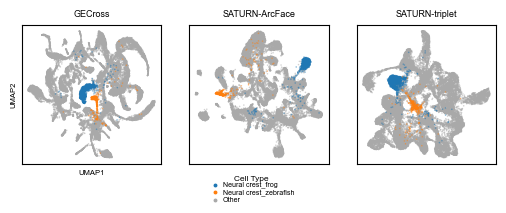

In [22]:
mode_args={'targets':['Neural crest']}
multi_umaps_drawing(adata_file_list,titles,'target_celltypes',mode_args,'figs5a')

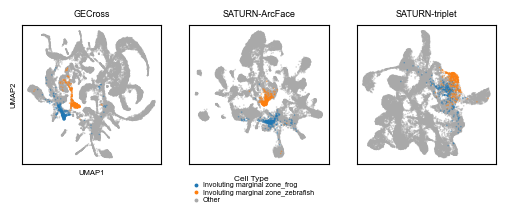

In [26]:
mode_args={'targets':['Involuting marginal zone']}
multi_umaps_drawing(adata_file_list,titles,'target_celltypes',mode_args,'figs5b')

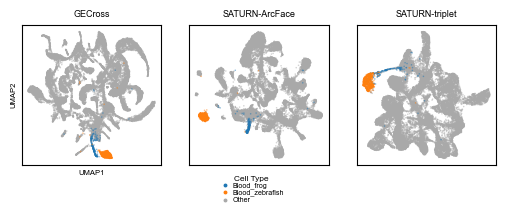

In [165]:
mode_args={'targets':['Blood']}
multi_umaps_drawing(adata_file_list,titles,'target_celltypes',mode_args)
#another example of gapped alignment

# Draw statistic‌s of cell embeddings

## Functions

### Get statistic‌s functions

In [2]:
def get_cross_species_homo_vs_non_homo_distance_ratios(adata_file_name,ordered_common_celltypes):
    dist_ratios_by_cell_type={}
    for cell_type in ordered_common_celltypes:
        dist_ratios_by_cell_type[cell_type]=[]

    embedding_adata=sc.read(f'./use_data/Save_for_Drawing/{adata_file_name}')
    mask=embedding_adata.obs.query("not cell_type.str.endswith('_subcenter')").index
    embedding_adata_filtered=embedding_adata[mask,:].copy()
    adata=embedding_adata_filtered
    
    for species in adata.obs['species'].unique():
        for cell_type in ordered_common_celltypes:
            cond1=adata.obs['species'].values==species
            cond2=adata.obs['cell_type'].values==cell_type

            idx_anchor=np.where(cond1 &cond2)[0]
            idx_pos=np.where(~cond1 &cond2)[0]
            idx_neg=np.where(~cond1 &~cond2)[0]
            X_anchor=adata.X[idx_anchor]
            X_pos=adata.X[idx_pos]
            X_neg=adata.X[idx_neg]
            # you need to change the distance calculation code to 'random sampling N pairs' logic, if anchor*pos,anchor*neg are too large
            dist_pos=cdist(X_anchor,X_pos,metric='cosine')
            dist_neg=cdist(X_anchor,X_neg,metric='cosine')

            mean_pos=np.mean(dist_pos,axis=-1)
            mean_neg=np.mean(dist_neg,axis=-1)
            mean_neg=np.where(mean_neg==0,np.finfo(float).eps,mean_neg)

            dist_ratios=np.round(mean_pos/mean_neg,4)
            dist_ratios_by_cell_type[cell_type].extend(dist_ratios)
    return {'distance_ratios_by_cell_type':dist_ratios_by_cell_type}

In [3]:
def get_cross_species_knn_purity_and_accuracy(adata_file_name,ordered_common_celltypes,K=5):
    knn_purities_by_cell_type,knn_accuracys_by_cell_type={},{}
    for cell_type in ordered_common_celltypes:
        knn_purities_by_cell_type[cell_type]=[]
        knn_accuracys_by_cell_type[cell_type]=[]

    embedding_adata=sc.read(f'./use_data/Save_for_Drawing/{adata_file_name}')
    mask=embedding_adata.obs.query("not cell_type.str.endswith('_subcenter')").index
    embedding_adata_filtered=embedding_adata[mask,:].copy()
    adata=embedding_adata_filtered

    for species in adata.obs['species'].unique():
        cond1=adata.obs['species'].values==species
        cond2=adata.obs['cell_type'].values.isin(ordered_common_celltypes)
        idx_species=np.where(cond1 &cond2)[0]
        idx_others=np.where(~cond1)[0]
        
        X_species=adata.X[idx_species]
        X_others=adata.X[idx_others]
        labels_species=adata.obs['cell_type'].values[idx_species]
        labels_others=adata.obs['cell_type'].values[idx_others]
        
        nn=NearestNeighbors(n_neighbors=K,metric='cosine').fit(X_others)
        _,neighbors_idx=nn.kneighbors(X_species) # shape:(len(idx_species),k)

        for i in range(len(idx_species)):
            cell_type=labels_species[i]
            neighbor_cell_types=[]
            for j in neighbors_idx[i]:
                neighbor_cell_types.append(labels_others[j])

            knn_purities_by_cell_type[cell_type].append(neighbor_cell_types.count(cell_type)/K)
            most_common_neighbor_cell_type,_=Counter(neighbor_cell_types).most_common(1)[0]
            if most_common_neighbor_cell_type==cell_type:
                knn_accuracys_by_cell_type[cell_type].append(1.0)
            else:
                knn_accuracys_by_cell_type[cell_type].append(0.0)
    return {'knn_purities_by_cell_type':knn_purities_by_cell_type,'knn_accuracys_by_cell_type':knn_accuracys_by_cell_type}

In [4]:
def get_cross_species_random_baseline_knn_purity_and_accuracy(adata_file_name,ordered_common_celltypes,K=5,random_times_per_sample=10):
    random_baseline_acc_count=[0,0]
    random_baseline_purity_count=[0,0]

    embedding_adata=sc.read(f'./use_data/Save_for_Drawing/{adata_file_name}')
    mask=embedding_adata.obs.query("not cell_type.str.endswith('_subcenter')").index
    embedding_adata_filtered=embedding_adata[mask,:].copy()
    adata=embedding_adata_filtered

    for species in adata.obs['species'].unique():
        cond1=adata.obs['species'].values==species
        cond2=adata.obs['cell_type'].values.isin(ordered_common_celltypes)
        idx_species=np.where(cond1 &cond2)[0]
        idx_others=np.where(~cond1)[0]

        labels_species=adata.obs['cell_type'].values[idx_species]
        labels_others=adata.obs['cell_type'].values[idx_others]
        for i in range(len(idx_species)):
            cell_type=labels_species[i]
            acc_count,purity_count=0,0
            for times in range(random_times_per_sample):
                random_neighbor_cell_types=random.sample(list(labels_others),K)

                purity_count+=random_neighbor_cell_types.count(cell_type)/K
                if Counter(random_neighbor_cell_types).most_common(1)[0]==cell_type:
                    acc_count+=1
            random_baseline_acc_count[0]+=acc_count/random_times_per_sample
            random_baseline_acc_count[1]+=1
            random_baseline_purity_count[0]+=purity_count/random_times_per_sample
            random_baseline_purity_count[1]+=1
    random_baseline_acc=round(random_baseline_acc_count[0]/random_baseline_acc_count[1],4)
    random_baseline_purity=round(random_baseline_purity_count[0]/random_baseline_purity_count[1],4)
    return {'random_baseline_acc':random_baseline_acc,'random_baseline_purity':random_baseline_purity}

### Draw statistic‌s functions

In [5]:
def draw_violin_plot_of_distance_ratios(to_draw_distance_ratios_by_cell_type,to_draw_methods):
    all_ratios=[]
    all_methods=[]
    for distance_ratios_by_cell_type,method_name in zip(to_draw_distance_ratios_by_cell_type,to_draw_methods):
        method_ratios=[]
        for ratios in distance_ratios_by_cell_type.values():
            method_ratios.extend(ratios)
        all_ratios.extend(method_ratios)
        all_methods.extend([method_name]*len(method_ratios))
    
    data=pd.DataFrame({
        'ratio':all_ratios,
        'method':all_methods
    })

    figsize_ratio=(7,5)
    figsize_x=0.48*(18.3/2.54) #figwidth=0.48*textwidth;textwidth=183mm;1inch=2.54cm
    figsize_y=figsize_ratio[1]*figsize_x/figsize_ratio[0]
    
    with plt.rc_context({'font.size':6}):
        plt.figure(figsize=(figsize_x,figsize_y))
        sns.violinplot(data=data,x='method',y='ratio',hue='method',palette='colorblind',legend=False)
        plt.axhline(y=1,color='gray',linestyle=':',linewidth=1.5,alpha=0.7)
        plt.ylabel('Cross-species distance ratio\n (homologous vs. non-homologous)')
        plt.xlabel(None)
        plt.tight_layout()
        plt.savefig(f'./save_drawing/cell_embedding_statistics/distance_ratio_violin.pdf',bbox_inches=None)
        plt.show()

In [24]:
def draw_point_plot_of_knn_purities_or_accuracys(to_draw_knn_metrics_by_cell_type,to_draw_methods,K,random_baseline,metric_name='accuracy'):
    all_metrics=[]
    all_methods=[]
    for knn_metrics_by_cell_type,method_name in zip(to_draw_knn_metrics_by_cell_type,to_draw_methods):
        method_metrics=[]
        for metrics in knn_metrics_by_cell_type.values():
            method_metrics.extend(metrics)
        all_metrics.extend(method_metrics)
        all_methods.extend([method_name]*len(method_metrics))
    
    data=pd.DataFrame({'metric':all_metrics,'method':all_methods})

    figsize_ratio=(7,5)
    figsize_x=0.48*(18.3/2.54) #figwidth=0.48*textwidth;textwidth=183mm;1inch=2.54cm
    figsize_y=figsize_ratio[1]*figsize_x/figsize_ratio[0]

    with plt.rc_context({'font.size':6}):
        plt.figure(figsize=(figsize_x,figsize_y))
        sns.pointplot(data=data, x='method',y='metric',hue='method',palette='colorblind',legend=False,errorbar=None,markers='o',markersize=6)
        plt.axhline(y=random_baseline,color='gray',linestyle=':',linewidth=1.5,alpha=0.7,label='Random baseline')
        plt.legend()
        plt.ylim(0,1)
        plt.ylabel(f'Cross-species kNN {metric_name} (k={K})')
        plt.xlabel(None)
        plt.tight_layout()
        plt.savefig(f'./save_drawing/cell_embedding_statistics/kNN_{metric_name}_pointplot(k={K}).pdf',bbox_inches=None)
        plt.show()

In [50]:
def draw_point_plot_of_cell_type_distance_ratios(to_draw_distance_ratios_by_cell_type,to_draw_methods,ordered_common_celltypes):
    figsize_ratio=(7,5)
    figsize_x=0.48*(18.3/2.54) #figwidth=0.48*textwidth;textwidth=183mm;1inch=2.54cm
    figsize_y=figsize_ratio[1]*figsize_x/figsize_ratio[0]

    with plt.rc_context({'font.size':5.01}):
        fig,axes=plt.subplots(1,len(to_draw_methods),figsize=(figsize_x,figsize_y),sharex=True,sharey=True)
        y_pos=np.arange(len(ordered_common_celltypes))

        for i,method in enumerate(to_draw_methods):
            ax=axes[i]
            cell_type_distance_ratios=[]
            for cell_type in ordered_common_celltypes:
                distance_ratio_list=to_draw_distance_ratios_by_cell_type[i][cell_type]
                cell_type_distance_ratio=np.mean(np.array(distance_ratio_list))
                cell_type_distance_ratios.append(cell_type_distance_ratio)
    
            ax.scatter(cell_type_distance_ratios,y_pos,s=8,c=None,alpha=0.8)
            ax.set_xlim(0,2)
            ax.axvline(x=1.0,color='gray',linestyle=':',linewidth=1.2,alpha=0.7)
            ax.set_facecolor('white')
            ax.set_title(method,y=0.98)

            if i==0:
                ax.set_yticks(y_pos)
                ax.set_yticklabels(ordered_common_celltypes)
                ax.invert_yaxis() #only once,because y is shared
                axis_pad=0.8
                ax.set_ylim(len(y_pos)-1+axis_pad,-axis_pad)
            else:
                ax.tick_params(left=False,labelleft=False)
        fig.supxlabel('Cross-species distance ratio (homologous vs. non-homologous)',x=0.62,y=0.015)
        plt.tight_layout(pad=0.5)
        plt.savefig(f'./save_drawing/cell_embedding_statistics/distance_ratio_by_cell_type.pdf',bbox_inches=None)
        plt.show()

In [48]:
def draw_bar_plot_of_cell_type_knn_purities_or_accuracys(to_draw_knn_metrics_by_cell_type,to_draw_methods,K,\
                                                         ordered_common_celltypes,metric_name='accuracy'):
    figsize_ratio=(7,5)
    figsize_x=0.48*(18.3/2.54) #figwidth=0.48*textwidth;textwidth=183mm;1inch=2.54cm
    figsize_y=figsize_ratio[1]*figsize_x/figsize_ratio[0]

    with plt.rc_context({'font.size':5.01}):
        fig,axes=plt.subplots(1,len(to_draw_methods),figsize=(figsize_x,figsize_y),sharex=True,sharey=True)
        y_pos=np.arange(len(ordered_common_celltypes))
    
        for i,method in enumerate(to_draw_methods):
            ax=axes[i]
            cell_type_knn_metrics=[]
            for cell_type in ordered_common_celltypes:
                knn_metric_list=to_draw_knn_metrics_by_cell_type[i][cell_type]
                cell_type_knn_metric=np.mean(np.array(knn_metric_list))
                cell_type_knn_metrics.append(cell_type_knn_metric)
    
            ax.barh(y_pos,cell_type_knn_metrics,height=0.6,alpha=0.8,color=None)
            ax.set_xlim(0,1)
            ax.set_xticks([0,0.5,1])
            ax.set_xticklabels(['0','0.5','1'])
            ax.set_facecolor('white')
            ax.set_title(method,y=0.98)
    
            if i==0:
                ax.set_yticks(y_pos)
                ax.set_yticklabels(ordered_common_celltypes)
                ax.invert_yaxis() #only once,because y is shared
                axis_pad=0.8
                ax.set_ylim(len(y_pos)-1+axis_pad,-axis_pad)
            else:
                ax.tick_params(left=False,labelleft=False)
        fig.supxlabel(f'Cross-species kNN {metric_name} (k={K})',x=0.62,y=0.015)
        plt.tight_layout(pad=0.5)
        plt.savefig(f'./save_drawing/cell_embedding_statistics/kNN_{metric_name}_by_cell_type(k={K}).pdf',bbox_inches=None)
        plt.show()

## Get statistic‌s of matched cell types

In [7]:
to_draw_files=['frog_zebrafish_95_epoch_embedding.h5ad','s_arcface_model_75_fixed_25_epoch_pretrain_embedding.h5ad',\
              's_triplet_model_100_fixed_25_epoch_pretrain_embedding.h5ad']
to_draw_methods=['GECross','SATURN-ArcFace','SATURN-triplet']
K=10

In [8]:
'''
# rank the common cell types by total cell nums
df=pd.read_csv(f'./data/processed_data/frog_zebrafish_cell_type_map.csv')
same_type_rows=df[df['frog_cell_type']==df['zebrafish_cell_type']]
same_types=same_type_rows['frog_cell_type']
print(f'total {len(same_types)} matched cell types')

cell_type_count_dict={}
for cell_type in same_types:
    cell_type_count_dict[cell_type]=0

for adata_file_name in to_draw_files:
    adata=sc.read(f'./use_data/Save_for_Drawing/{adata_file_name}')
    all_counts=adata.obs['cell_type'].value_counts()
    for cell_type in cell_type_count_dict.keys():
        cell_type_count_dict[cell_type]+=all_counts[cell_type]

sorted_items=sorted(cell_type_count_dict.items(),key=lambda x:x[1],reverse=True)
sorted_cell_type_count_dict=dict(sorted_items)
ordered_common_celltypes=list(sorted_cell_type_count_dict.keys())
print(sorted_cell_type_count_dict)
'''

ordered_common_celltypes=['Hindbrain','Forebrain/midbrain','Intermediate mesoderm','Epidermal progenitor','Neuroectoderm',\
                          'Non-neural ectoderm','Neural crest','Placodal area','Presomitic mesoderm','Neuron','Tailbud','Optic',\
                          'Skeletal muscle','Blood','Involuting marginal zone','Endoderm','Eye primordium','Endothelial','Ionocyte',\
                          'Notochord','Heart','Otic placode','Lens','Olfactory placode','Notoplate','Rohon-beard neuron','Hatching gland','Germline']

In [9]:
# get cross species homo vs non homo distance ratio scores
to_draw_distance_ratios_by_cell_type=[]

for adata_file_name in to_draw_files:
    r_dict=get_cross_species_homo_vs_non_homo_distance_ratios(adata_file_name,ordered_common_celltypes)
    #print(f'In {adata_file_name},')
    #for key,value in r_dict.items():
        #print(key,': ',value)
    to_draw_distance_ratios_by_cell_type.append(r_dict['distance_ratios_by_cell_type'])

In [10]:
# get cross species knn purity and accuracy scores
to_draw_knn_accuracys_by_cell_type,to_draw_knn_purities_by_cell_type=[],[]
random_baseline_acc=0

for adata_file_name in to_draw_files:
    r_dict=get_cross_species_knn_purity_and_accuracy(adata_file_name,ordered_common_celltypes,K=K)
    #print(f'In {adata_file_name},')
    #for key,value in r_dict.items():
        #print(key,': ',value)
    to_draw_knn_accuracys_by_cell_type.append(r_dict['knn_accuracys_by_cell_type'])
    to_draw_knn_purities_by_cell_type.append(r_dict['knn_purities_by_cell_type'])

In [229]:
# get random baseline knn purity and accuracy mean
# the random baseline is different every time due to random sampling approach, we use 0.045 as final for random_baseline_purity
random_times_per_sample=10
for i,adata_file_name in enumerate(to_draw_files):
    print(f'for {to_draw_methods[i]},')
    r_dict=get_cross_species_random_baseline_knn_purity_and_accuracy(adata_file_name,ordered_common_celltypes,K,random_times_per_sample)
    to_draw_random_baseline_purity=r_dict['random_baseline_purity']
    to_draw_random_baseline_acc=r_dict['random_baseline_acc']
    print('random_baseline_purity: ',to_draw_random_baseline_purity)
    print('random_baseline_acc: ',to_draw_random_baseline_acc)

for GECross,
random_baseline_purity:  0.0448
random_baseline_acc:  0.0
for SATURN-ArcFace,
random_baseline_purity:  0.0449
random_baseline_acc:  0.0
for SATURN-triplet,
random_baseline_purity:  0.0446
random_baseline_acc:  0.0


In [11]:
to_draw_random_baseline_purity=0.045
to_draw_random_baseline_acc=0.0

In [12]:
# some print
for i,method_name in enumerate(to_draw_methods):
    print(method_name)
    all_values=[]
    for key,values in to_draw_distance_ratios_by_cell_type[i].items():
        all_values.extend(values)
    print('mean distance ratio is:')
    print(round(np.mean(all_values),4))

print('\n')
for i,method_name in enumerate(to_draw_methods):
    print(method_name)
    all_values=[]
    for key,values in to_draw_knn_accuracys_by_cell_type[i].items():
        all_values.extend(values)
    print('mean knn accuracys is:')
    print(round(np.mean(all_values),4))

GECross
mean distance ratio is:
0.3696
SATURN-ArcFace
mean distance ratio is:
0.8653
SATURN-triplet
mean distance ratio is:
0.5934


GECross
mean knn accuracys is:
0.5963
SATURN-ArcFace
mean knn accuracys is:
0.4355
SATURN-triplet
mean knn accuracys is:
0.4048


## Draw statistic‌s of matched cell types

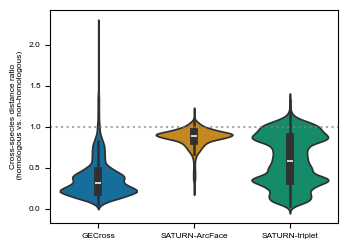

In [14]:
draw_violin_plot_of_distance_ratios(to_draw_distance_ratios_by_cell_type,to_draw_methods)

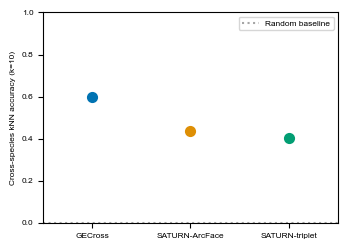

In [25]:
draw_point_plot_of_knn_purities_or_accuracys(to_draw_knn_accuracys_by_cell_type,to_draw_methods,K,to_draw_random_baseline_acc,metric_name='accuracy')

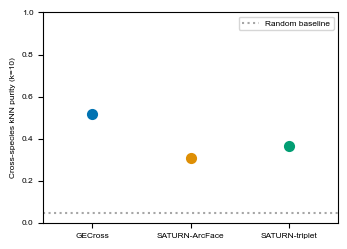

In [26]:
draw_point_plot_of_knn_purities_or_accuracys(to_draw_knn_purities_by_cell_type,to_draw_methods,K,to_draw_random_baseline_purity,metric_name='purity')

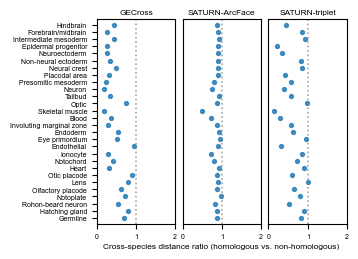

In [51]:
draw_point_plot_of_cell_type_distance_ratios(to_draw_distance_ratios_by_cell_type,to_draw_methods,ordered_common_celltypes)

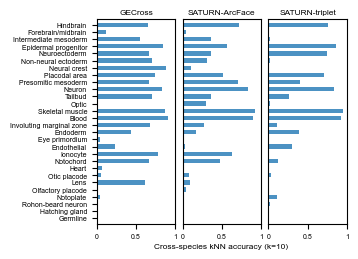

In [49]:
draw_bar_plot_of_cell_type_knn_purities_or_accuracys(to_draw_knn_accuracys_by_cell_type,to_draw_methods,K,\
                                                     ordered_common_celltypes,metric_name='accuracy')

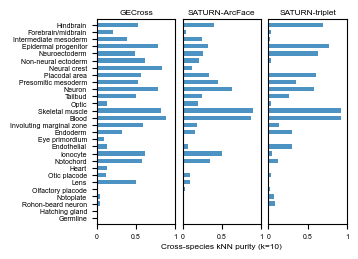

In [53]:
draw_bar_plot_of_cell_type_knn_purities_or_accuracys(to_draw_knn_purities_by_cell_type,to_draw_methods,K,\
                                                     ordered_common_celltypes,metric_name='purity')

In [ ]:
# Observation:
# When K=1 (nearest neighbour), all methods perform worst. Unstable as expected.
# As K gradually increases to 200, the knn_accuracy continues to rise.
# While the knn_purity starts to decline when K reaches 80.

# Finally choose K=10 for evaluation and comparison, as the purpose is to measure embedding quality rather than label transfer,
# and a smaller K captures local characteristics.

# Draw statistic‌s of cell embeddings (heatmap plus)

## Functions

### Get statistic‌s functions

In [2]:
# function for only two species heatmap painting
# similar as knn accuracy, but count matches of any type
def get_cross_species_knn_matches(adata_file_name,species1,species2,K=5):
    matches_dict={}
    final_matches_dict={}

    embedding_adata=sc.read(f'./use_data/Save_for_Drawing/{adata_file_name}')
    mask=embedding_adata.obs.query("not cell_type.str.endswith('_subcenter')").index
    embedding_adata_filtered=embedding_adata[mask,:].copy()
    adata=embedding_adata_filtered
    
    species1_celltypes=adata[adata.obs['species']==species1].obs['cell_type'].unique()
    species2_celltypes=adata[adata.obs['species']==species2].obs['cell_type'].unique()
    #print(f'{species1} has {len(species1_celltypes)} celltypes, {species2} has {len(species2_celltypes)} celltypes')

    for cell_type in species1_celltypes:
        matches_dict[cell_type]={}
        final_matches_dict[cell_type]={}
        for cell_type2 in species2_celltypes:
            matches_dict[cell_type][cell_type2]={'matches1':0,'all1':0,'matches2':0,'all2':0}
            final_matches_dict[cell_type][cell_type2]=0

    for i,species in enumerate([species1,species2]):
        cond1=adata.obs['species'].values==species
        idx_species=np.where(cond1)[0]
        idx_others=np.where(~cond1)[0]

        X_species=adata.X[idx_species]
        X_others=adata.X[idx_others]
        labels_species=adata.obs['cell_type'].values[idx_species]
        labels_others=adata.obs['cell_type'].values[idx_others]

        nn=NearestNeighbors(n_neighbors=K,metric='cosine').fit(X_others)
        _,neighbors_idx=nn.kneighbors(X_species) # shape:(len(idx_species),k)

        for j in range(len(idx_species)):
            cell_type=labels_species[j]
            neighbor_cell_types=[]
            for k in neighbors_idx[j]:
                neighbor_cell_types.append(labels_others[k])

            most_common_neighbor_cell_type,_=Counter(neighbor_cell_types).most_common(1)[0]
            if i==0: # species1 as anchor
                for cell_type2 in species2_celltypes:
                    matches_dict[cell_type][cell_type2]['all1']+=1
                matches_dict[cell_type][most_common_neighbor_cell_type]['matches1']+=1
            elif i==1: # species2 as anchor
                for cell_type2 in species1_celltypes:
                    matches_dict[cell_type2][cell_type]['all2']+=1
                matches_dict[most_common_neighbor_cell_type][cell_type]['matches2']+=1

    for cell_type in species1_celltypes:
        for cell_type2 in species2_celltypes:
            rate1=matches_dict[cell_type][cell_type2]['matches1']/matches_dict[cell_type][cell_type2]['all1']
            rate2=matches_dict[cell_type][cell_type2]['matches2']/matches_dict[cell_type][cell_type2]['all2']
            final_matches_dict[cell_type][cell_type2]=np.round((rate1+rate2)/2,4)
    return {'final_matches_dict':final_matches_dict}

### Draw statistic‌s functions

In [19]:
def draw_multiple_cross_species_knn_heatmap(to_draw_knn_matches,titles,ordered_common_celltypes,species1_name,species2_name,K):
    n=len(to_draw_knn_matches)
    species1_celltypes=list(set().union(*(d.keys() for d in to_draw_knn_matches)))
    species2_celltypes=list(set().union(*(next(iter(d.values())).keys() for d in to_draw_knn_matches)))

    row_order=ordered_common_celltypes+sorted(set(species1_celltypes)-set(ordered_common_celltypes))
    col_order=ordered_common_celltypes+sorted(set(species2_celltypes)-set(ordered_common_celltypes))

    color_palette=sns.color_palette('tab20',n_colors=len(ordered_common_celltypes))
    common_color_dict={ct:color_palette[i] for i,ct in enumerate(ordered_common_celltypes)}
    other_color='lightgrey'
    row_colors=[common_color_dict[ct] if ct in common_color_dict else other_color for ct in row_order]
    col_colors=[common_color_dict[ct] if ct in common_color_dict else other_color for ct in col_order]

    mats=[]
    for knn_match in to_draw_knn_matches:
        mat=np.zeros((len(row_order),len(col_order)))
        for i,ct1 in enumerate(row_order):
            for j,ct2 in enumerate(col_order):
                mat[i,j]=knn_match.get(ct1,{}).get(ct2,0.0)
        mats.append(mat)

    figsize_ratio=(2+9*n,10)
    if n==1:
        figsize_x=0.6*(18.3/2.54) #figwidth=0.6*textwidth;textwidth=183mm;1inch=2.54cm
        figsize_y=figsize_ratio[1]*figsize_x/figsize_ratio[0]
    elif n==2:
        figsize_x=0.96*(18.3/2.54) #figwidth=0.96*textwidth;textwidth=183mm;1inch=2.54cm
        figsize_y=figsize_ratio[1]*figsize_x/figsize_ratio[0]
    else:
        figsize_x,figsize_y=figsize_ratio
    if n==1:
        fig,axes=plt.subplots(1,n,figsize=(figsize_x,figsize_y),squeeze=False,
                            gridspec_kw={'left':0.24,'right': 0.9,'bottom': -0.15,'top':1.35})
    else:
        fig,axes=plt.subplots(1,n,figsize=(figsize_x,figsize_y),squeeze=False,
                            gridspec_kw={'left':0.132,'right': 0.938,'bottom':-0.136,'top':1.36,'wspace':0.015})

    axes=axes[0]
    for idx in range(n):
        ax=axes[idx]
        sns.heatmap(mats[idx],xticklabels=col_order,yticklabels=row_order,cmap='viridis',vmin=0,vmax=1,annot=False,ax=ax,cbar=False)
        ax.set_title(titles[idx],fontsize=6,pad=3)
        ax.tick_params(axis='x',labelsize=5.01)
        ax.tick_params(axis='y',labelsize=5.01)
        ax.set_aspect('equal') 

        ax.tick_params(axis='both',length=0)
        if idx==0:
            ax.set_ylabel(species1_name+' cell types',fontsize=5.5,labelpad=-2)
            ax.spines['left'].set_visible(False)
            for j,color in enumerate(row_colors):
                rect=Rectangle(
                    (-0.6,j),0.6,1,transform=ax.transData,
                    facecolor=color,edgecolor='none',
                    clip_on=False,zorder=1
                )
                ax.add_patch(rect)
        else:
            ax.tick_params(axis='y',labelleft=False,left=False)

        for j,color in enumerate(col_colors):
            rect=Rectangle(
                (j,len(row_order)),1,0.6,
                transform=ax.transData,
                facecolor=color,edgecolor='none',
                clip_on=False,zorder=1
            )
            ax.add_patch(rect)
    if n==1:
        fig.supxlabel(species2_name+' cell types',x=0.57,y=0.04,fontsize=5.5)
    else:
        fig.supxlabel(species2_name+' cell types',x=0.55,y=0.003,fontsize=5.5)

    norm=plt.Normalize(vmin=0,vmax=1)
    sm=plt.cm.ScalarMappable(cmap='viridis',norm=norm)
    sm.set_array([])
    if n==1:
        cbar_ax=fig.add_axes([0.91,0.33,0.01,0.55]) #[left,bottom,width,hight]
    else:
        cbar_ax=fig.add_axes([0.942,0.33,0.01,0.55])
    cbar=fig.colorbar(sm,cax=cbar_ax)

    cbar.outline.set_visible(False)
    for spine in cbar_ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_edgecolor('black')
    dy=0.003
    cbar_ax.spines['bottom'].set_position(('axes',dy))
    cbar_ax.spines['top'].set_position(('axes',1+0.0025))
    cbar_ax.spines['left'].set_bounds(dy,1+0.0025)
    cbar_ax.spines['right'].set_bounds(dy,1+0.0025)
    
    cbar_ax.tick_params(axis='y',labelsize=5.01)
    cbar.set_label('Symmetrized cross-species kNN matching score',fontsize=5.2)
    return fig,axes

## Get statistic‌s of all cell types

In [177]:
K=10
titles=['GECross','SATURN-triplet']

to_draw_files=['frog_zebrafish_95_epoch_embedding.h5ad','s_triplet_model_100_fixed_25_epoch_pretrain_embedding.h5ad']
to_draw_knn_matches=[]
for adata_file_name in to_draw_files:
    r_dict=get_cross_species_knn_matches(adata_file_name,'frog','zebrafish',K)
    #print(f'In {adata_file_name},')
    #for key,value in r_dict.items():
        #print(key,': ',value)
    to_draw_knn_matches.append(r_dict['final_matches_dict'])

In [4]:
# common cell types ordered same as previous sections ( others are ordered by alphabet )
ordered_common_celltypes=['Hindbrain','Forebrain/midbrain','Intermediate mesoderm','Epidermal progenitor','Neuroectoderm',\
                          'Non-neural ectoderm','Neural crest','Placodal area','Presomitic mesoderm','Neuron','Tailbud','Optic',\
                          'Skeletal muscle','Blood','Involuting marginal zone','Endoderm','Eye primordium','Endothelial','Ionocyte',\
                          'Notochord','Heart','Otic placode','Lens','Olfactory placode','Notoplate','Rohon-beard neuron','Hatching gland','Germline']

## Draw statistic‌s of all cell types

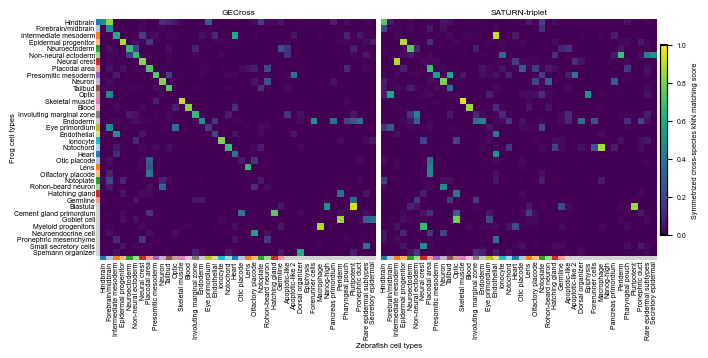

In [420]:
fig,ax=draw_multiple_cross_species_knn_heatmap(to_draw_knn_matches,titles,ordered_common_celltypes,species1_name='Frog',species2_name='Zebrafish',K=10)
plt.savefig(f'./save_drawing/cell_embedding_statistics/matching_score_heatmap.pdf',bbox_inches=None)
plt.show()

In [6]:
#plus
K=10
plus_titles=['SATURN-ArcFace']

to_draw_files=['s_arcface_model_75_fixed_25_epoch_pretrain_embedding.h5ad']
plus_to_draw_knn_matches=[]
for adata_file_name in to_draw_files:
    r_dict=get_cross_species_knn_matches(adata_file_name,'frog','zebrafish',K)
    #print(f'In {adata_file_name},')
    #for key,value in r_dict.items():
        #print(key,': ',value)
    plus_to_draw_knn_matches.append(r_dict['final_matches_dict'])

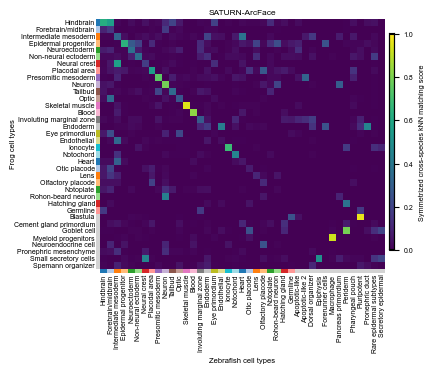

In [20]:
fig,ax=draw_multiple_cross_species_knn_heatmap(plus_to_draw_knn_matches,plus_titles,ordered_common_celltypes,species1_name='Frog',species2_name='Zebrafish',K=10)
plt.savefig(f'./save_drawing/cell_embedding_statistics/plus_matching_score_heatmap.pdf',bbox_inches=None)
plt.show()

## Calculate statistical metrics

In [423]:
for i,title in enumerate(titles+plus_titles):
    print(f'For {title}')
    knn_matches=(to_draw_knn_matches+plus_to_draw_knn_matches)[i]

    threshold=0.6
    true_positive_count=0
    false_positive_count=0
    for key1 in knn_matches.keys():
        for key2 in knn_matches[key1].keys():
            if knn_matches[key1][key2]>threshold:
                if key1==key2:
                    true_positive_count+=1
                else:
                    false_positive_count+=1
    print(f'true_positive_count={true_positive_count},false_positive_count={false_positive_count}')
    print(f'precision is {np.round(true_positive_count/(true_positive_count+false_positive_count),4)}')

For GECross
true_positive_count=15,false_positive_count=6
precision is 0.7143
For SATURN-triplet
true_positive_count=7,false_positive_count=7
precision is 0.5
For SATURN-ArcFace
true_positive_count=7,false_positive_count=3
precision is 0.7


## human & mouse & lemur clustermap 

### Functions

In [136]:
def get_celltype_sim_matrix(adata_file_name):
    embedding_adata=sc.read(f'./use_data/Save_for_Drawing/{adata_file_name}')
    mask=embedding_adata.obs.query("not cell_type.str.endswith('_subcenter')").index
    embedding_adata_filtered=embedding_adata[mask,:].copy()
    adata=embedding_adata_filtered

    X=adata.X
    if hasattr(X,"toarray"):
        X=X.toarray()
    
    groups=adata.obs['species'].astype(str).str[0].str.upper()+'_'+adata.obs['cell_type'].astype(str)
    unique_groups=pd.unique(groups)

    group_means={}
    for g in unique_groups:
        mask=(groups==g)
        group_means[g]=X[mask].mean(axis=0)

    group_labels=sorted(group_means.keys())
    all_means=np.array([group_means[g] for g in group_labels])

    sim_matrix=cosine_similarity(all_means)
    sim_df=pd.DataFrame(sim_matrix,index=group_labels,columns=group_labels)
    return sim_df

In [291]:
def draw_clustermap(sim_df,save_name='clustermap',scale_y=1.0):
    mapsize_ratio=(1,1)
    mapsize_x=0.85*(18.3/2.54)
    mapsize_y=mapsize_ratio[1]*mapsize_x/mapsize_ratio[0]
    
    g=sns.clustermap(
        sim_df,
        cmap='viridis',figsize=(mapsize_x,scale_y*mapsize_y),
        row_cluster=True,col_cluster=True,dendrogram_ratio=(0.0,0.15),
        xticklabels=False,yticklabels=True,
        cbar_pos=(0.82,0.3,0.02,0.4),
        vmin=0,vmax=1,
        tree_kws={'linestyle':'solid','linewidth':0.5,'color':'black'}
    )

    g.ax_heatmap.tick_params(axis='y',labelsize=5.01)
    #g.cax.set_frame_on(True)
    #g.cax.spines[:].set_linewidth(0.5)
    #g.cax.spines[:].set_color('black')

    g.cax.set_ylabel('Similarity score',fontsize=5.5)
    g.cax.tick_params(labelsize=5.1)

    plt.savefig(f'./save_drawing/cell_embedding_statistics/{save_name}.pdf',bbox_inches='tight')
    plt.show()

In [234]:
def compute_block_score(sim_df):
    scores={}
    for idx in sim_df.index:
        row=sim_df.loc[idx]
        row=row.drop(idx)


        top_k=int(max(1,len(row)*0.1))
        top_mean=row.nlargest(top_k).mean()

        bottom_k=int(len(row)*0.5)
        bottom_mean=row.nsmallest(bottom_k).mean()
        
        scores[idx]=top_mean-bottom_mean
    return pd.Series(scores).sort_values(ascending=False)

In [265]:
def select_clustered_subset(sim_df,top_n_point=20,threshold=0.75,top_n_communities=3):
    block_scores=compute_block_score(sim_df)
    candidate_labels=block_scores.head(top_n_point).index.tolist()
    sim_df=sim_df.loc[candidate_labels,candidate_labels]
    
    G=nx.Graph()
    labels = sim_df.index.tolist()
    G.add_nodes_from(labels)
    
    for i,row_label in enumerate(labels):
        for j,col_label in enumerate(labels):
            if i>=j:
                continue
            sim=sim_df.iloc[i,j]
            if sim>threshold:
                G.add_edge(row_label,col_label,weight=sim)
    
    communities=list(louvain_communities(G,weight='weight',seed=42))
    
    communities_sorted=sorted(communities,key=len,reverse=True)
    selected=[]
    for comm in communities_sorted[:top_n_communities]:
        selected.extend(list(comm))
    return selected

### Draw

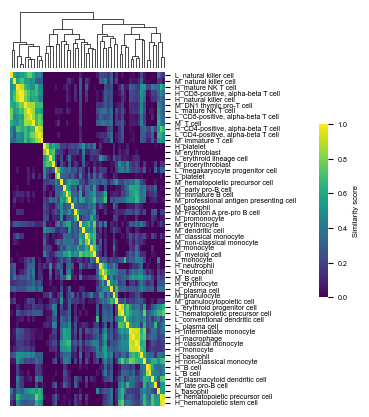

In [271]:
adata_file_name='human_mouse_lemur_95_epoch_embedding.h5ad'

sim_df=get_celltype_sim_matrix(adata_file_name)
sim_df=sim_df.clip(lower=0)
draw_clustermap(sim_df,save_name='clustermap_all')

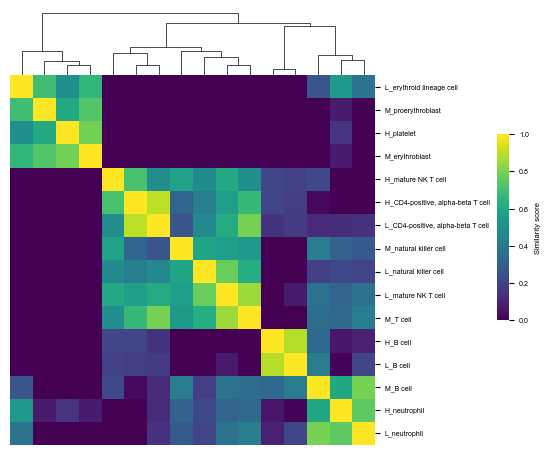

In [296]:
adata_file_name='human_mouse_lemur_95_epoch_embedding.h5ad'

sim_df=get_celltype_sim_matrix(adata_file_name)
sim_df=sim_df.clip(lower=0)

#select=select_clustered_subset(sim_df,top_n_point=20,threshold=0.75,top_n_communities=4)
select=['L_natural killer cell','M_natural killer cell','H_mature NK T cell','L_mature NK T cell',
        'H_CD4-positive, alpha-beta T cell','L_CD4-positive, alpha-beta T cell','M_T cell',
        'H_platelet','M_erythroblast','L_erythroid lineage cell','M_proerythroblast',
        'H_neutrophil','L_neutrophil','M_B cell','H_B cell','L_B cell']
draw_clustermap(sim_df.loc[select,select],save_name='clustermap',scale_y=0.76)

# Gene associated cell embedding analysis

## Functions

### Analysis functions

In [2]:
def align_cell_embedding_with_gene_expression(all_species,embedding_adata):
    species_align_dict={}

    mask=embedding_adata.obs.query("not cell_type.str.endswith('_subcenter')").index
    embedding_adata=embedding_adata[mask,:].copy()

    mission_name='Frog_Zebrafish_2000hv_60000cell'
    embedding_type='ESM1b'
    for species in all_species:
        with open(f'./use_data/Save_DataSet/{mission_name}/{embedding_type}_{species}_process_return.pkl','rb') as f:
            process_return=pickle.load(f)
            expression_adata=sc.AnnData(X=process_return['X'].to_dense().numpy())
            expression_adata.obs_names=process_return['cell_names']
            expression_adata.var_names=process_return['gene_names']

            gene_embedding_dict={}
            for i,gene_name in enumerate(process_return['gene_names']):
                gene_embedding_dict[gene_name]=process_return['embedding_ref'][i]

        common_cells=expression_adata.obs_names.intersection(embedding_adata.obs_names)
        expression_adata=expression_adata[common_cells].copy()
        _embedding_adata=embedding_adata[common_cells].copy()
        expression_adata.obs['species']=_embedding_adata.obs['species'].values
        expression_adata.obs['cell_type']=_embedding_adata.obs['cell_type'].values

        #keep only cell_type with more than 10 cells, for meaningful analysis
        cell_counts=embedding_adata.obs['cell_type'].value_counts()
        min_cells=10
        keep_types=cell_counts[cell_counts>=min_cells].index.tolist()
        expression_adata=expression_adata[expression_adata.obs['cell_type'].isin(keep_types)].copy()
        embedding_adata=embedding_adata[embedding_adata.obs['cell_type'].isin(keep_types)].copy()

        species_align_dict[species]={'expression_adata':expression_adata,'embedding_adata':_embedding_adata,'gene_embedding_dict':gene_embedding_dict}
    return species_align_dict

In [95]:
def get_celltype_specific_marker_genes(expression_adata,to_query_cell_type,exclude_prefixes=['si:','zgc:','wu:']):
    celltype_result_dict={}
    adata=expression_adata.copy()
    sc.tl.rank_genes_groups(adata,groupby='cell_type',method='wilcoxon',key_added='rank_genes',pts=True)
    df=sc.get.rank_genes_groups_df(adata,group=to_query_cell_type,key='rank_genes')

    mask=adata.obs['cell_type']==to_query_cell_type
    expr_type=adata[mask].X
    mean_exprs=[]
    for gene in df['names']:
        if gene in adata.var_names:
            gene_idx=adata.var_names.get_loc(gene)
            gene_vals=expr_type[:,gene_idx]
            if hasattr(gene_vals,'toarray'):
                gene_vals=gene_vals.toarray().flatten()
            mean_exprs.append(np.mean(gene_vals))
        else:
            mean_exprs.append(0.0)
    df['mean_expr']=mean_exprs
    df_filtered=df[(df['pvals_adj']<0.05) & (df['logfoldchanges']>1) & (df['pct_nz_group']>0.3)]

    if exclude_prefixes is not None:
        for prefix in exclude_prefixes:
            df_filtered=df_filtered[~df_filtered['names'].str.startswith(prefix)]
    
    df_filtered=df_filtered.reset_index(drop=True)
    return df_filtered

import warnings
warnings.simplefilter(action='ignore',category=pd.errors.PerformanceWarning)

### Draw functions

In [96]:
def celltype_expr_dotplot(ax,data_dict,groupby='cell_type',gene_axis_place='right',size_scale=None):
    title,adata,celltype_list,gene_list=data_dict['title'],data_dict['adata'],data_dict['celltype_list'],data_dict['gene_list']
    
    adata=adata[adata.obs[groupby].isin(celltype_list)].copy()
    expr_df=adata.to_df()[gene_list]
    expr_df[groupby]=adata.obs[groupby].values

    mean_df=expr_df.groupby(groupby,observed=True)[gene_list].mean()
    frac_df=expr_df.groupby(groupby,observed=True)[gene_list].apply(lambda g:(g>0).mean())

    mean_df=mean_df.reindex(celltype_list)
    frac_df=frac_df.reindex(celltype_list)

    if gene_axis_place=='left' or gene_axis_place=='right':
        mean_mat=mean_df.T
        frac_mat=frac_df.T
        row_labels=gene_list
        col_labels=mean_df.index.tolist()
    else: # gene_axis_place=='down'
        mean_mat=mean_df
        frac_mat=frac_df
        row_labels=mean_df.index.tolist()
        col_labels=gene_list

    n_rows,n_cols=mean_mat.shape

    ax.set_title(title,fontsize=6.5,pad=6)
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(col_labels,fontsize=5.5,rotation=90,ha='center',va='top')
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels(row_labels,fontsize=5.5)
    ax.set_xlim(-0.5,n_cols-0.5)
    ax.set_ylim(-0.5,n_rows-0.5)
    ax.set_aspect('equal')
    ax.grid(False)

    if gene_axis_place=='right':
        ax.tick_params(axis='y',labelleft=False,labelright=True,left=False,right=True)

    def get_size_scale(ax,dot_max_ratio=0.6):
        bbox=ax.get_window_extent()
        disp0=ax.transData.transform((0,0))
        disp1=ax.transData.transform((1,0))
        unit_length_pts=abs(disp1[0]-disp0[0])
        max_diameter_pts=unit_length_pts*dot_max_ratio
        size_scale=np.pi*(max_diameter_pts/2)**2
        return size_scale
    if size_scale is None:
        fig=ax.figure
        fig.canvas.draw()
        size_scale=get_size_scale(ax)

    norm=mcolors.Normalize(vmin=0,vmax=mean_mat.values.max() if mean_mat.values.max()>0 else 1)
    smap=plt.cm.ScalarMappable(cmap='viridis',norm=norm)
    smap.set_array([])

    for i in range(n_rows):
        for j in range(n_cols):
            frac=frac_mat.iloc[i,j]
            mean_expr=mean_mat.iloc[i,j]
            if frac>0:
                size=frac*size_scale
                color=smap.to_rgba(mean_expr)
                ax.scatter(j,i,s=size,c=[color],edgecolors='grey',linewidths=0.3)
    return ax,smap,size_scale

In [97]:
def draw_cross_species_celltype_expr_dotplot(data_left,data_right=None,sim_score_matrix=None,change_configs={}):
    drawing_configs={'cell_size':0.2,'sim_score_threshold':2,'suptitle_y':1.1,'show_legend':True,'legend_width':0.4,\
                    'gap_width':1.0,'line_to_axis_offset':1.8,\
                    'per_legend_hight':0.5,'legend_gap':0.4}
    for key in change_configs:
        drawing_configs[key]=change_configs[key]

    left_n_genes=len(data_left['gene_list'])
    right_n_genes=len(data_right['gene_list'])
    left_n_ct=len(data_left['celltype_list'])
    right_n_ct=len(data_right['celltype_list'])

    cell_size=drawing_configs['cell_size']
    gap_width,legend_width=drawing_configs['gap_width'],drawing_configs['legend_width']
    if drawing_configs['show_legend'] is not True:
        legend_width=0

    left_w=left_n_ct*cell_size
    left_h=left_n_genes*cell_size
    right_w=right_n_ct*cell_size
    right_h=right_n_genes*cell_size

    total_w=left_w+gap_width+right_w+legend_width
    total_h=max(left_h,right_h)
    fig=plt.figure(figsize=(total_w,total_h))
    print('total_w',total_w,'total_h',total_h)

    left_rect=[0,0,left_w/total_w,left_h/total_h]
    gap_rect=[left_w/total_w,0,gap_width/total_w,total_h/total_h]
    right_rect=[(left_w+gap_width)/total_w,0,right_w/total_w,right_h/total_h]

    ax_left=fig.add_axes(left_rect)
    ax_gap=fig.add_axes(gap_rect)
    ax_gap.set_axis_off()
    ax_right=fig.add_axes(right_rect)    
    if data_left['title_main']:
        fig.suptitle(data_left['title_main'],fontsize=6.7,x=(left_w+0.5*gap_width)/total_w,y=drawing_configs['suptitle_y'])

    ax_left,smap_left,size_scale_left=celltype_expr_dotplot(ax_left,data_left,gene_axis_place='right')
    ax_right,smap_right,_= celltype_expr_dotplot(ax_right,data_right,gene_axis_place='left',size_scale=size_scale_left)

    if sim_score_matrix is not None:
        lw_min,lw_max=0.5,1.5
        threshold=drawing_configs['sim_score_threshold']
        max_score=3.0

        left_x=ax_left.get_xlim()[1]+drawing_configs['line_to_axis_offset']
        right_x=ax_right.get_xlim()[0]-drawing_configs['line_to_axis_offset']

        n_left,n_right=sim_score_matrix.shape
        for i in range(n_left):
            for j in range(n_right):
                score=sim_score_matrix[i,j]
                if score>threshold:
                    score=min(score,max_score)
                    lw=lw_min+(lw_max-lw_min)*(score-threshold)/(max_score-threshold)
                    con=ConnectionPatch(
                        xyA=(left_x,i),coordsA=ax_left.transData,
                        xyB=(right_x,j),coordsB=ax_right.transData,
                        axesA=ax_left,axesB=ax_right,
                        color='grey',linewidth=lw,alpha=0.8
                    )
                    ax_gap.add_artist(con)
                    ax_left.plot(left_x,i,'o',color='grey',markersize=lw+0.5,clip_on=False)
                    ax_right.plot(right_x,j,'o',color='grey',markersize=lw+0.5,clip_on=False)

    if drawing_configs['show_legend'] is True:
        legend_pad=0.2
        leg_x=left_w+gap_width+right_w+legend_pad
        leg_w=legend_width

        dot_h,cbar_h,line_h=drawing_configs['per_legend_hight'],drawing_configs['per_legend_hight'],drawing_configs['per_legend_hight']
        row_spacer=drawing_configs['legend_gap']
        total_leg_h=dot_h+cbar_h+line_h+2*row_spacer
        leg_y_start=(total_h-total_leg_h)/2

        dot_y=leg_y_start+cbar_h+line_h+2*row_spacer
        dot_ax=fig.add_axes([leg_x/total_w,dot_y/total_h,leg_w/total_w,dot_h/total_h])
        cbar_y=leg_y_start+line_h+row_spacer
        cbar_ax=fig.add_axes([leg_x/total_w,cbar_y/total_h,leg_w/total_w,cbar_h/total_h])
        line_y=leg_y_start
        line_ax=fig.add_axes([leg_x/total_w,line_y/total_h,leg_w/total_w,line_h/total_h])

        dot_ax.set_xlim(0,1)
        dot_ax.set_ylim(0,1)
        dot_ax.axis('off')
        cbar_ax.set_xlim(0,1)
        cbar_ax.set_ylim(0,1)
        cbar_ax.axis('off')
        line_ax.set_xlim(0,1)
        line_ax.set_ylim(0,1)
        line_ax.axis('off')
        
        dot_ax.text(0.5,0.9,'Fraction of cells\nin group (%)',ha='center',fontsize=6)
        fracs=[0.5,0.75,1.0]
        xs=np.linspace(0.05,0.9,len(fracs))
        y_dot=0.5
        for xi, f in zip(xs,fracs):
            size=f*size_scale_left
            dot_ax.scatter(xi,y_dot,s=size,c='grey',edgecolors='grey',linewidths=0.3,clip_on=False)
            dot_ax.plot([xi,xi],[y_dot-0.3,y_dot-0.4],color='black',linewidth=0.5)
            dot_ax.text(xi,y_dot-0.5,f'{int(f*100)}',ha='center',va='top',fontsize=6)

        cbar_ax.text(0.5,0.9,'Mean expression\nin group',ha='center',fontsize=6)
        vmax=max(smap_left.norm.vmax,smap_right.norm.vmax)
        norm=mcolors.Normalize(vmin=0,vmax=vmax)
        smap_legend=plt.cm.ScalarMappable(cmap=smap_left.cmap, norm=norm)
        inner_cbar_ax=cbar_ax.inset_axes([0.05,0.4,0.9,0.2])
        cbar=fig.colorbar(smap_legend,cax=inner_cbar_ax,orientation='horizontal')
        cbar.outline.set_visible(False)
        for spine in inner_cbar_ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.8)
            spine.set_edgecolor('black')
        dy=0.06
        inner_cbar_ax.spines['bottom'].set_position(('axes',dy))
        inner_cbar_ax.spines['top'].set_position(('axes',1+dy))
        
        cbar.set_ticks([vmax/2,vmax])
        cbar.set_ticklabels([f'{vmax/2:.1f}', f'{vmax:.1f}'],fontsize=6)

        line_ax.text(0.5,0.9,'Gene similarity\nscore',ha='center',fontsize=6)
        lw_min,lw_max=0.5,1.5
        sc_min,sc_max=drawing_configs['sim_score_threshold'],3.0
        scores=[sc_min,(sc_min+sc_max)/2,sc_max]
        lws=[lw_min+(lw_max-lw_min)*(s-sc_min)/(sc_max-sc_min) for s in scores]

        y_lines=np.linspace(0.6,0.1,len(scores))
        for y,lw,s in zip(y_lines,lws,scores):
            line_ax.plot([0.2,0.6],[y,y],color='grey',linewidth=lw,solid_capstyle='butt',clip_on=False)
            line_ax.text(0.7,y,f'{s:.1f}',va='center',fontsize=6)

    return fig,(ax_left,ax_gap,ax_right)

In [98]:
def get_sim_score_matrix(gene_emb_left,gene_emb_right):
    left_mat=torch.stack(gene_emb_left)
    right_mat=torch.stack(gene_emb_right)
    left_normed=left_mat/left_mat.norm(dim=1,keepdim=True)
    right_normed=right_mat/right_mat.norm(dim=1,keepdim=True)
    sim=torch.mm(left_normed,right_normed.T)

    eps=1e-10
    sim_score=-torch.log10(torch.clamp(1.0-sim,min=eps))
    return sim_score

In [99]:
 def draw_celltype_differential_expr_dotplot(species_align_dict,title_main,titles,all_species,celltype_list,to_query_cell_type,TOP_N=15,change_configs={}):
    species_gene_list={}
    for species in all_species:
        expression_adata=species_align_dict[species]['expression_adata']
        differential_adata=get_celltype_specific_marker_genes(expression_adata,to_query_cell_type)
        species_gene_list[species]=list(differential_adata.head(TOP_N).names)

    gene_list_left=species_gene_list[all_species[0]][::-1]
    gene_list_right=species_gene_list[all_species[1]][::-1]

    data_left={
        'title_main':title_main,
        'title':titles[0],
        'adata':species_align_dict[all_species[0]]['expression_adata'],
        'celltype_list':celltype_list,
        'gene_list':gene_list_left,
    }
    data_right={
        'title':titles[1], 
        'adata':species_align_dict[all_species[1]]['expression_adata'],
        'celltype_list':celltype_list,
        'gene_list':gene_list_right,
    }

    gene_emb_left=[species_align_dict[all_species[0]]['gene_embedding_dict'][key] for key in gene_list_left]
    gene_emb_right=[species_align_dict[all_species[1]]['gene_embedding_dict'][key] for key in gene_list_right]
    sim_score_matrix=get_sim_score_matrix(gene_emb_left,gene_emb_right)

    draw_cross_species_celltype_expr_dotplot(data_left,data_right,sim_score_matrix,change_configs)

In [100]:
def gene_expression_in_umap_drawing(embedding_adata,expression_adatas,to_add_gene_names,expr_name,all_species):
    mask=embedding_adata.obs.query("not cell_type.str.endswith('_subcenter')").index
    embedding_adata_filtered=embedding_adata[mask,:].copy()
    adata=embedding_adata_filtered

    adata.obs[to_add_gene_names]=0.0
    for gene_name in to_add_gene_names: 
        for expression_adata in expression_adatas:
            if gene_name in expression_adata.var_names:
                expr=expression_adata[:,gene_name].X
                expr=np.array(expr).flatten()
                expr_series=pd.Series(expr,index=expression_adata.obs_names)
                adata.obs[gene_name]+=(expr_series.reindex(adata.obs_names).fillna(0).values)

    adata.obs[expr_name]=adata.obs[to_add_gene_names].sum(axis=1)

    sc.pp.pca(adata)
    sc.pp.neighbors(adata,random_state=0)
    sc.tl.umap(adata,random_state=0)

    figsize_ratio=(1,1)
    figsize_x=0.48*(18.3/2.54) #figwidth=0.48*textwidth;textwidth=183mm;1inch=2.54cm
    figsize_y=figsize_ratio[1]*figsize_x/figsize_ratio[0]
    
    for species in all_species:
        fig,ax=plt.subplots(figsize=(figsize_x,figsize_y),constrained_layout=True)
        to_draw_adata=adata[adata.obs['species']==species].copy()
        to_draw_adata=to_draw_adata[to_draw_adata.obs[expr_name].argsort()[::-1]].copy()  # rank to highlight high expression

        with plt.rc_context({'axes.titlesize':6.5,'ytick.labelsize':5.5}):
            sc.pl.umap(to_draw_adata,color=expr_name,alpha=0.8,size=8,\
            title=f'{expr_name} expression in {species}',ax=ax,show=False)

        ax.set_box_aspect(1)
        ax.set_xlabel('UMAP1',fontsize=5.5)
        ax.set_ylabel('UMAP2',fontsize=5.5)

        for collection in ax.collections:
            if isinstance(collection,mcollections.PathCollection):
                collection.set_rasterized(True)
        fig.savefig(f'./save_drawing/gene_associated_cell_embedding_analysis/{expr_name} expression in {species}.pdf',dpi=300,bbox_inches=None)
        plt.show()

In [101]:
 def draw_given_gene_expr_dotplot(species_align_dict,title_main,titles,all_species,celltype_list,given_genes,change_configs={}):
    gene_list_left=given_genes[all_species[0]][::-1]
    gene_list_right=given_genes[all_species[1]][::-1]

    data_left={
        'title_main':title_main,
        'title':titles[0],
        'adata':species_align_dict[all_species[0]]['expression_adata'],
        'celltype_list':celltype_list,
        'gene_list':gene_list_left,
    }
    data_right={
        'title':titles[1], 
        'adata':species_align_dict[all_species[1]]['expression_adata'],
        'celltype_list':celltype_list,
        'gene_list':gene_list_right,
    }

    gene_emb_left=[species_align_dict[all_species[0]]['gene_embedding_dict'][key] for key in gene_list_left]
    gene_emb_right=[species_align_dict[all_species[1]]['gene_embedding_dict'][key] for key in gene_list_right]
    sim_score_matrix=get_sim_score_matrix(gene_emb_left,gene_emb_right)

    draw_cross_species_celltype_expr_dotplot(data_left,data_right,sim_score_matrix,change_configs)

##  Analyse and Draw

In [102]:
# only analysing cells appeared in the embedding adata, with genes that was used for producing the embeddings.
all_species=['frog','zebrafish']
embedding_adata_name='frog_zebrafish_95_epoch_embedding.h5ad'
embedding_adata=sc.read(f'./use_data/Save_for_Drawing/{embedding_adata_name}')
species_align_dict=align_cell_embedding_with_gene_expression(all_species,embedding_adata)

total_w 3.0 total_h 3.0


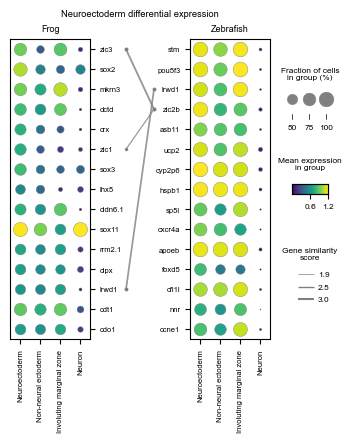

In [357]:
title_main='Neuroectoderm differential expression'
titles=['Frog','Zebrafish']
all_species=['frog','zebrafish']
celltype_list=['Neuroectoderm','Non-neural ectoderm','Involuting marginal zone','Neuron']
to_query_cell_type='Neuroectoderm'
TOP_N=15

change_configs={'sim_score_threshold':1.9,\
               'cell_size':0.2,'suptitle_y':1.1,'legend_width':0.4,'gap_width':1.0,'line_to_axis_offset':1.8}
draw_celltype_differential_expr_dotplot(species_align_dict,title_main,titles,all_species,celltype_list,to_query_cell_type,TOP_N,change_configs)
plt.savefig(f'./save_drawing/gene_associated_cell_embedding_analysis/Neuroectoderm_differential_expression.pdf',bbox_inches='tight')
plt.show()

total_w 2.6 total_h 3.0


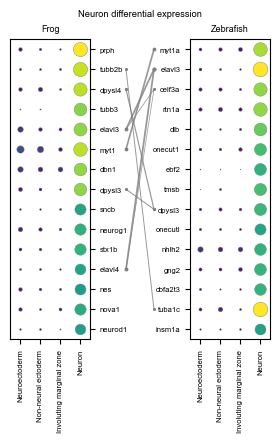

In [358]:
title_main='Neuron differential expression'
titles=['Frog','Zebrafish']
all_species=['frog','zebrafish']
celltype_list=['Neuroectoderm','Non-neural ectoderm','Involuting marginal zone','Neuron']
to_query_cell_type='Neuron'
TOP_N=15

change_configs={'sim_score_threshold':1.9,'show_legend':False,\
               'cell_size':0.2,'suptitle_y':1.1,'gap_width':1.0,'line_to_axis_offset':1.8}

draw_celltype_differential_expr_dotplot(species_align_dict,title_main,titles,all_species,celltype_list,to_query_cell_type,TOP_N,change_configs)
plt.savefig(f'./save_drawing/gene_associated_cell_embedding_analysis/Neuron_differential_expression.pdf',bbox_inches='tight')
plt.show()

total_w 2.1999999999999997 total_h 3.0


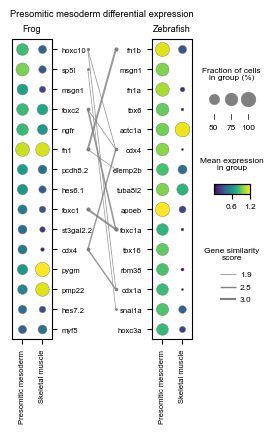

In [360]:
title_main='Presomitic mesoderm differential expression'
titles=['Frog','Zebrafish']
all_species=['frog','zebrafish']
celltype_list=['Presomitic mesoderm','Skeletal muscle']
to_query_cell_type='Presomitic mesoderm'
TOP_N=15

change_configs={'sim_score_threshold':1.9,\
                'cell_size':0.2,'suptitle_y':1.1,'legend_width':0.4,'gap_width':1.0,'line_to_axis_offset':1.8}

draw_celltype_differential_expr_dotplot(species_align_dict,title_main,titles,all_species,celltype_list,to_query_cell_type,TOP_N,change_configs)
plt.savefig(f'./save_drawing/gene_associated_cell_embedding_analysis/Presomitic_mesoderm_differential_expression.pdf',bbox_inches='tight')
plt.show()

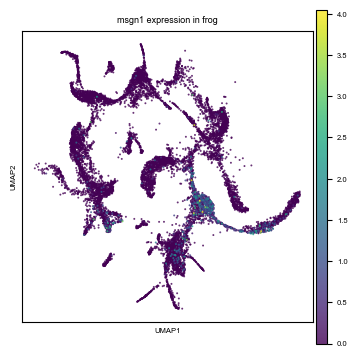

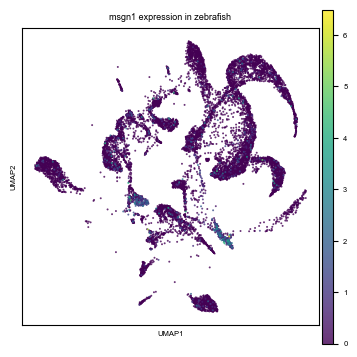

In [150]:
all_species=['frog','zebrafish']

embedding_adata_name='frog_zebrafish_95_epoch_embedding.h5ad'
embedding_adata=sc.read(f'./use_data/Save_for_Drawing/{embedding_adata_name}')

expression_adatas=[]
for species in all_species:
    expression_adatas.append(species_align_dict[species]['expression_adata'])

to_add_gene_names=['msgn1']
expr_name='msgn1'
gene_expression_in_umap_drawing(embedding_adata,expression_adatas,to_add_gene_names,expr_name,all_species)

total_w 3.0 total_h 1.4000000000000001


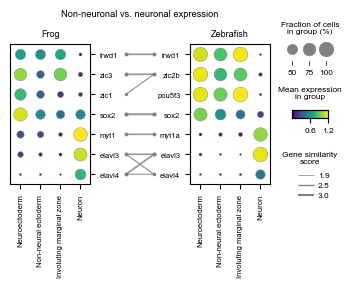

In [366]:
title_main='Non-neuronal vs. neuronal expression'
titles=['Frog','Zebrafish']
all_species=['frog','zebrafish']
celltype_list=['Neuroectoderm','Non-neural ectoderm','Involuting marginal zone','Neuron']

change_configs={'sim_score_threshold':1.9,\
               'cell_size':0.2,'suptitle_y':1.25,'legend_width':0.4,'gap_width':1.0,'line_to_axis_offset':1.8,\
               'per_legend_hight':0.4,'legend_gap':0.25}

given_genes={'frog':['lrwd1','zic3','zic1','sox2','myt1','elavl3','elavl4'], #'sp5l',...,'dpysl3'
            'zebrafish':['lrwd1','zic2b','pou5f3','sox2','myt1a','elavl3','elavl4']} #'sp5l',...,'dpysl3'
draw_given_gene_expr_dotplot(species_align_dict,title_main,titles,all_species,celltype_list,given_genes,change_configs)
plt.savefig(f'./save_drawing/gene_associated_cell_embedding_analysis/fig2c.pdf',bbox_inches='tight')
plt.show()

# Subcenter related cell-subgroup analysis

## Functions

In [6]:
def assign_to_subcenters(adata_cells,adata_subcenters,keep_ratio=None):
    all_species=set(adata_subcenters.obs['species'].unique())
    adata_cells.obs['subcenter_assignment']='unassigned'
    can_draw_subcenters=set() 
    for species in all_species:
        query_mask=adata_cells.obs['species']==species
        ref_mask=adata_subcenters.obs['species']==species
        query_X=adata_cells[query_mask].X
        ref_X=adata_subcenters[ref_mask].X
        distances=pairwise_distances(query_X,ref_X,metric='cosine')

        min_dist_idx=np.argmin(distances,axis=1)
        min_distances=distances[np.arange(distances.shape[0]),min_dist_idx]

        assigned_subcenters=np.array(adata_subcenters[ref_mask].obs_names)[min_dist_idx]
        can_draw_subcenters.update(assigned_subcenters)
        adata_cells.obs.loc[query_mask,'subcenter_assignment']=assigned_subcenters

        if keep_ratio is not None:
            to_assign_idx=np.where(query_mask)[0]
            groups={}
            for i,subcenter in enumerate(assigned_subcenters):
                groups.setdefault(subcenter,[]).append((min_distances[i],i))

            outlier_mask=np.zeros(len(to_assign_idx),dtype=bool)
            for sub,items in groups.items():
                n_keep=max(1,int(len(items)*keep_ratio))
                items.sort(key=lambda x:x[0])
                for _,i in items[n_keep:]:
                    outlier_mask[i]=True

            adata_cells.obs['subcenter_assignment'].values[to_assign_idx[outlier_mask]]='unassigned'
    return adata_cells,can_draw_subcenters

In [9]:
#save file only when there is prefix
def draw_target_sub_celltypes(adata_file_name,targets,legend_loc='lower right',show_type='all',prefix=None):
    embedding_adata=sc.read(f'./use_data/Save_for_Drawing/{adata_file_name}')

    targets_subcenters=[t+'_subcenter' for t in targets]
    cell_mask=embedding_adata.obs['cell_type'].isin(targets)
    subcenter_mask=embedding_adata.obs['cell_type'].isin(targets_subcenters)
    
    adata_cells=embedding_adata[cell_mask,:].copy()
    adata_subcenters=embedding_adata[subcenter_mask,:].copy()
    _,can_draw_subcenters=assign_to_subcenters(adata_cells,adata_subcenters)
    #can_draw_subcenters=['frog_Endoderm_subcenter_2'] #can show frog_Endoderm_subcenter_2 is the one farther‌ from zebrafish_Endoderm_subcenter_0

    if show_type=='all':
        mask=embedding_adata.obs['cell_type'].isin(targets) | \
            embedding_adata.obs_names.isin(can_draw_subcenters) | \
             ~(embedding_adata.obs['cell_type'].str.endswith('_subcenter'))
    else:
        mask=embedding_adata.obs['cell_type'].isin(targets) | \
            embedding_adata.obs_names.isin(can_draw_subcenters)
    embedding_adata_filtered=embedding_adata[mask,:].copy()
    adata=embedding_adata_filtered

    adata.obs['cell_type']=adata.obs['cell_type'].cat.add_categories('Subcenter')
    subcenter_mask=adata.obs['cell_type'].str.endswith('_subcenter')
    adata.obs.loc[subcenter_mask,'cell_type']='Subcenter'
    adata.obs['cell_type']=adata.obs['cell_type'].cat.remove_unused_categories()

    sc.pp.pca(adata) #also necessary for umap
    sc.pp.neighbors(adata,random_state=0)
    sc.tl.umap(adata,random_state=0)

    captions=[]
    all_species=sorted(adata.obs['species'].unique())
    adata.obs['_cell_type']='Other'
    for target in targets+['Subcenter']:
        for species in all_species:
            condition=(adata.obs['cell_type']==target)&(adata.obs['species']==species)
            if target!='Subcenter':
                adata.obs.loc[condition,'_cell_type']=target+'_'+species
                captions.append(target+'_'+species)
            else:
                adata.obs.loc[condition,'_cell_type']=species+'_Subcenter'
    if len(captions)<=2:
        palette=sns.color_palette("tab10",len(captions))
    if len(captions)<=12:
        palette=sns.color_palette("Paired",len(captions))
    else:
        palette=sns.color_palette("tab20",len(captions))

    color_dict=dict(zip(captions,palette))
    subcenter_colors=['#E41A1C','#FF7F00','#984EA3']
    for i,species in enumerate(all_species):
        color_dict[f'{species}_Subcenter']=subcenter_colors[i]
    color_dict['Other']='darkgrey'

    adata.obs['_cell_type']=pd.Categorical(adata.obs['_cell_type'],categories=color_dict.keys(),ordered=True) # to order the caption

    mask_subcenter=adata.obs['_cell_type'].str.endswith('_Subcenter',na=False)
    mask_others=adata.obs['_cell_type']=='Other'
    idx_subcenter=np.where(mask_subcenter)[0]
    idx_others=np.where(mask_others)[0]
    idx_normal=np.where(~mask_subcenter & ~mask_others)[0]
    new_order=np.concatenate([idx_others,idx_normal,idx_subcenter])
    _adata=adata[new_order,:].copy()

    point_sizes=np.concatenate([
        np.full(len(idx_others)+len(idx_normal),8),
        np.full(len(idx_subcenter),30)
    ])
    alphas=np.concatenate([
        np.full(len(idx_others)+len(idx_normal),0.5),
        np.full(len(idx_subcenter),0.7)
    ])

    figsize_ratio=(1,1)
    figsize_x=0.48*(18.3/2.54) #figwidth=0.48*textwidth;textwidth=183mm;1inch=2.54cm
    figsize_y=figsize_ratio[1]*figsize_x/figsize_ratio[0]

    fig,ax=plt.subplots(figsize=(figsize_x,figsize_y),constrained_layout=True)

    with plt.rc_context({'axes.titlesize':6.5,'legend.fontsize':5.1,}):
        sc.pl.umap(_adata,color="_cell_type",palette=color_dict,alpha=alphas,size=point_sizes,
                   edgecolor='none',title="Cell Type",ax=ax,legend_loc=legend_loc,show=False)

    ax.set_box_aspect(1)
    ax.set_xlabel('UMAP1',fontsize=5.5)
    ax.set_ylabel('UMAP2',fontsize=5.5)
    legend=ax.get_legend()
    if legend is not None:
        frame=legend.get_frame()
        frame.set_alpha(0.5)

    for collection in ax.collections:
        if isinstance(collection,mcollections.PathCollection):
            collection.set_rasterized(True)

    if prefix is not None:
        target=targets[0].replace('/','-') # express 'or' without being interpreted as a file separator
        if len(targets)>1:
            target=target+'_mixed'
            #target=target+f'_mixed_{str(int(time.time()))}' # if need more version of mixed drawing
        plt.savefig(f'./save_drawing/subcenter_related/{prefix}_{target}_sub_embedding_show.pdf',bbox_inches=None,dpi=300)
    plt.show()

In [10]:
# need to use function "align_cell_embedding_with_gene_expression" in section "Gene associated cell embedding analysis"

In [11]:
def draw_volcano_plot(adata,group_name,title=None,show_name_genes=None):
    fc_threshold=1.0 
    p_threshold=0.05

    uns_dict=adata.uns['rank_genes_groups']
    df=pd.DataFrame({
        'gene':uns_dict['names'][group_name],
        'log2FC':uns_dict['logfoldchanges'][group_name],
        'p_val_adj':uns_dict['pvals_adj'][group_name]
    })

    df['regulation']='Not significant'
    df.loc[(df['log2FC']>fc_threshold) & (df['p_val_adj']<p_threshold),'regulation']='Up'
    df.loc[(df['log2FC']<-fc_threshold) & (df['p_val_adj']<p_threshold),'regulation']='Down'

    print(f'Num total genes: {len(df)}')
    print(f"Num Up-regulated genes: {(df['regulation']=='Up').sum()}")
    print(f"Num Down-regulated genes: {(df['regulation']=='Down').sum()}")

    figsize_ratio=(1,1)
    figsize_x=0.48*(18.3/2.54) #figwidth=0.48*textwidth;textwidth=183mm;1inch=2.54cm
    figsize_y=figsize_ratio[1]*figsize_x/figsize_ratio[0]

    fig,ax=plt.subplots(figsize=(figsize_x,figsize_y),constrained_layout=True)

    color_map={
        'Up':'red',
        'Down':'blue',
        'Not significant':'lightgrey'
    }

    order_draw=['Not significant','Down','Up']
    for reg in order_draw:
        subset=df[df['regulation']==reg]
        color=color_map[reg]
        rast=False
        if reg=='Not significant':
            rast=True
        ax.scatter(subset['log2FC'],-np.log10(subset['p_val_adj']),c=color,s=5,alpha=0.6,label=reg,rasterized=rast,zorder=2)

    ax.axhline(y=-np.log10(p_threshold),color='black',linestyle='--',linewidth=0.5,zorder=1)
    ax.axvline(x=fc_threshold,color='black',linestyle='--',linewidth=0.5,zorder=1)
    ax.axvline(x=-fc_threshold,color='black',linestyle='--',linewidth=0.5,zorder=1)

    ax.set_xlabel('log2(Fold Change)',fontsize=6)
    ax.set_ylabel('-log10(adjusted P-value)',fontsize=6)
    ax.tick_params(axis='both',labelsize=5.5)

    if title is not None:
        ax.set_title(title,fontsize=6.5)

    handles,labels=ax.get_legend_handles_labels()
    handles_dict=dict(zip(labels,handles))
    order_labels=list(color_map.keys())
    order_handles=[handles_dict[reg] for reg in order_labels]
    ax.legend(order_handles,order_labels,frameon=True,framealpha=0.5,prop={'size':6})

    if show_name_genes is not None:
        texts=[]
        for gene in show_name_genes:
            row=df[df['gene']==gene]
            texts.append(ax.text(row['log2FC'].iloc[0],-np.log10(row['p_val_adj'].iloc[0]),gene,fontsize=5.5,ha='center',va='bottom'))
        adjust_text(texts,arrowprops=dict(arrowstyle='->',color='black',lw=0.5))
    return fig,ax

In [67]:
def draw_gene_pathway_map(pathways,genes,pathway_gene_dict,pathway_id_to_brief_name_dict,gene_log2fc_value_dict):
    pathway_names=[pathway_id_to_brief_name_dict[p] for p in pathways]
    df_matrix=pd.DataFrame(index=pathway_names,columns=genes,dtype=float)
    for pathway in pathways:
        for gene in genes:
            if gene in pathway_gene_dict[pathway]:
                pathway_name=pathway_id_to_brief_name_dict[pathway]
                df_matrix.loc[pathway_name,gene]=gene_log2fc_value_dict[gene]
    
    figsize_ratio=(14,5)
    figsize_x=0.85*(18.3/2.54) #figwidth=0.85*textwidth;textwidth=183mm;1inch=2.54cm
    figsize_y=figsize_ratio[1]*figsize_x/figsize_ratio[0]

    fig,ax=plt.subplots(figsize=(figsize_x,figsize_y),constrained_layout=True)
    ax.set_facecolor('#E8E8E8')

    sns.heatmap(df_matrix,
                annot=True,fmt='.1f',
                cmap='RdBu_r',center=0,
                linewidths=0.5,
                linecolor='black',
                mask=df_matrix.isnull(),
                cbar_kws={'shrink':0.8},
                square=True,
                annot_kws={'size':5.5,'weight':'bold'})

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=5.1)
    cbar.set_label(label='log2FC (Distant vs. Prox.)',fontsize=5.1)
    
    plt.title('Pathways of Distant vs. Proximate DEGs',fontsize=6.5,pad=8)
    plt.xlabel('Genes',fontsize=6)
    plt.ylabel('Pathways',fontsize=6)
    plt.xticks(rotation=45,ha='right',fontsize=5.5)
    plt.yticks(rotation=0,fontsize=6)
    return fig,ax

## Draw UMAP with activated subcenter

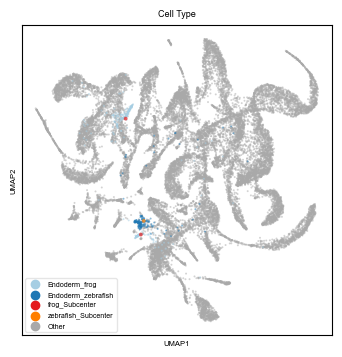

In [26]:
draw_target_sub_celltypes('frog_zebrafish_95_epoch_embedding.h5ad',['Endoderm'],\
                      'lower left','all','GECross')

## Analyse the gene expression of different close-to-subcenter-cell-subgroup 

In [7]:
adata_file_name='frog_zebrafish_95_epoch_embedding.h5ad'
targets=['Endoderm']
keep_ratio=0.9

embedding_adata=sc.read(f'./use_data/Save_for_Drawing/{adata_file_name}')

targets_subcenters=[t+'_subcenter' for t in targets]
cell_mask=embedding_adata.obs['cell_type'].isin(targets)
subcenter_mask=embedding_adata.obs['cell_type'].isin(targets_subcenters)

adata_cells=embedding_adata[cell_mask,:].copy()
adata_subcenters=embedding_adata[subcenter_mask,:].copy()
adata_cells,can_draw_subcenters=assign_to_subcenters(adata_cells,adata_subcenters,keep_ratio)

In [8]:
adata_cells.obs

,species,cell_type,subcenter_assignment
cell_name,,,
GAGCGGAA-ATACTCTT,frog,Endoderm,frog_Endoderm_subcenter_2
CAGGTTGC-ACCTTCTT,frog,Endoderm,frog_Endoderm_subcenter_2
AATTCAGTA-TACTTGTG,frog,Endoderm,unassigned
GTGCCCAT-CCCTAACC-1,frog,Endoderm,frog_Endoderm_subcenter_1
CTAGACTA-CAGTCCCT,frog,Endoderm,frog_Endoderm_subcenter_2
...,...,...,...
8293-4-5,zebrafish,Endoderm,zebrafish_Endoderm_subcenter_0
8295-1-4,zebrafish,Endoderm,zebrafish_Endoderm_subcenter_0
5487-2-3,zebrafish,Endoderm,zebrafish_Endoderm_subcenter_0


In [9]:
# only analysing cells appeared in the embedding adata, with genes that was used for producing the embeddings.
all_species=['frog','zebrafish']
r_dict=align_cell_embedding_with_gene_expression(all_species,adata_cells)
to_analyse_expression_adata=r_dict['frog']['expression_adata']
to_analyse_embedding_adata=r_dict['frog']['embedding_adata']

to_analyse_expression_adata.obs['subcenter_assignment']=to_analyse_embedding_adata.obs['subcenter_assignment'].values

to_analyse_expression_adata

AnnData object with n_obs × n_vars = 262 × 2000
    obs: 'species', 'cell_type', 'subcenter_assignment'

In [10]:
sc.tl.rank_genes_groups(to_analyse_expression_adata,groupby='subcenter_assignment', 
                        groups=['frog_Endoderm_subcenter_2'],# farther from zebrafish endoderm subcenter
                        reference='frog_Endoderm_subcenter_1',# nearer from it
                        method='wilcoxon')
to_analyse_expression_adata

AnnData object with n_obs × n_vars = 262 × 2000
    obs: 'species', 'cell_type', 'subcenter_assignment'
    uns: 'rank_genes_groups'

Num total genes: 2000
Num Up-regulated genes: 30
Num Down-regulated genes: 51


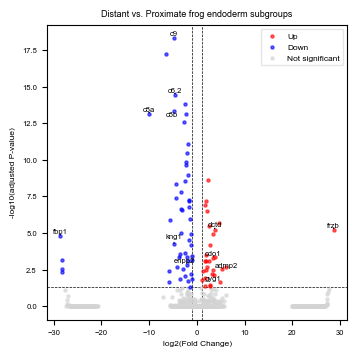

In [13]:
# show_name_genes are from following pathway analysis
show_name_genes=['frzb','admp2',\
                'c9','c6.2','c8b','c8a','kng1',\
                'fbp1','enpp2','gyg1','cdo1','dctd']

fig,ax=draw_volcano_plot(to_analyse_expression_adata,group_name='frog_Endoderm_subcenter_2',\
                         title='Distant vs. Proximate frog endoderm subgroups',show_name_genes=show_name_genes)
plt.savefig('./save_drawing/subcenter_related/frog_Endoderm_subcenter_2_vs_1_volcano.pdf',dpi=300,bbox_inches=None)
plt.show()

In [15]:
group_name='frog_Endoderm_subcenter_2'

uns_dict=to_analyse_expression_adata.uns['rank_genes_groups']
df=pd.DataFrame({
    'gene':uns_dict['names'][group_name],
    'log2FC':uns_dict['logfoldchanges'][group_name],
    'p_val_adj':uns_dict['pvals_adj'][group_name]
})

considered_UP_genes=list(df.loc[(df['log2FC']>3.0) & (df['p_val_adj']<0.01)]['gene'])
considered_DOWN_genes=list(df.loc[(df['log2FC']<-3.0) & (df['p_val_adj']<0.01)]['gene'])
print('considered_UP_genes:',considered_UP_genes)
print('considered_DOWN_genes:',considered_DOWN_genes)

considered_UP_genes: ['gs17', 'dctd', 'frzb', 'vegt', 'chp1', 'cdo1', 'crx', 'admp2', 'smagp', 'cldn4', 'gyg1']
considered_DOWN_genes: ['cpne3', 'cdh1', 'slc9a3r1', 'nkx2-6', 'vcan', 'slc6a14.2', 'enpp2', 'lsp1', 'kng1', 'fbp1', 'rhcg', 'slc3a2', 'ndrg1', 'mycn', 'cfi', 'cfd', 'anxa2', 'c8a', 'c8b', 'c6.2', 'c3', 'c9']


In [24]:
# gene_id searched from https://www.kegg.jp/
gene_name_to_id_dict={'c9':'xla:379504','c6.2':'xla:379126','c8b':'xla:108714245','c8a':'xla:443975',\
                      'anxa2':'xla:397735','cfd':'xla:494791','cfi':'xla:399318','mycn':'xla:100337516','ndrg1':'xla:380319',\
                      'slc3a2':'xla:379133','rhcg':'xla:108711456','fbp1':'xla:380220','kng1':'xla:494833','lsp1':'xla:100158343',\
                      'enpp2':'xla:735240','slc6a14.2':'xla:414614','vcan':'xla:100037127','nkx2-6':'xla:373736','slc9a3r1':'xla:495828',\
                      'cdh1':'xla:108714071','cpne3':'xla:495505',\
                      'gyg1':'xla:779133','cldn4':'xla:734640','smagp':'xla:108708609','admp2':'xla:100036830','crx':'xla:398118',\
                      'cdo1':'xla:398963','chp1':'xla:443801','vegt':'xla:397986','frzb':'xla:399085','dctd':'xla:414581','gs17':'xla:397898'}
# gene_id not found: c3
pathway_gene_dict={}
for gene in considered_UP_genes+considered_DOWN_genes:
    if gene in gene_name_to_id_dict:
        gene_id=gene_name_to_id_dict[gene]
        link_result=REST.kegg_link('pathway',gene_id).read()
        for line in link_result.strip().split('\n'):
            if line:
                pathway_id=line.split('\t')[-1]
                if pathway_id not in pathway_gene_dict:
                    pathway_gene_dict[pathway_id]=[]
                pathway_gene_dict[pathway_id].append(gene)
pathway_gene_dict

{'path:xla00240': ['dctd'],
 'path:xla01100': ['dctd', 'cdo1', 'gyg1', 'enpp2', 'fbp1'],
 'path:xla01232': ['dctd'],
 'path:xla04310': ['frzb'],
 'path:xla00270': ['cdo1'],
 'path:xla00430': ['cdo1'],
 'path:xla04060': ['admp2'],
 'path:xla04350': ['admp2'],
 'path:xla03272': ['cldn4'],
 'path:xla04382': ['cldn4'],
 'path:xla04514': ['cldn4', 'cdh1'],
 'path:xla04530': ['cldn4', 'slc9a3r1'],
 'path:xla00500': ['gyg1'],
 'path:xla04371': ['cdh1'],
 'path:xla04517': ['cdh1'],
 'path:xla04518': ['cdh1'],
 'path:xla04519': ['cdh1'],
 'path:xla04520': ['cdh1'],
 'path:xla05100': ['cdh1'],
 'path:xla00565': ['enpp2'],
 'path:xla04625': ['lsp1'],
 'path:xla04080': ['kng1'],
 'path:xla04810': ['kng1', 'c8a', 'c8b', 'c6.2', 'c9'],
 'path:xla00010': ['fbp1'],
 'path:xla00030': ['fbp1'],
 'path:xla00051': ['fbp1'],
 'path:xla01200': ['fbp1'],
 'path:xla04910': ['fbp1'],
 'path:xla04150': ['slc3a2'],
 'path:xla04216': ['slc3a2'],
 'path:xla05132': ['anxa2']}

In [93]:
to_show_pathway_ids=['path:xla04810','path:xla01100','path:xla04310','path:xla04350']
#'path:xla04060' is Cytokine-cytokine receptor interaction,
# not related with frzb's Wnt signaling pathway, so not use
pathway_id_to_name_dict={}
for pathway_id in to_show_pathway_ids:
    pathway_result=REST.kegg_get(pathway_id).read()
    name_line=pathway_result.strip().split('\n')[1]
    pathway_id_to_name_dict[pathway_id]=name_line
pathway_id_to_name_dict

{'path:xla04810': 'NAME        Regulation of actin cytoskeleton - Xenopus laevis (African clawed frog)',
 'path:xla01100': 'NAME        Metabolic pathways - Xenopus laevis (African clawed frog)',
 'path:xla04310': 'NAME        Wnt signaling pathway - Xenopus laevis (African clawed frog)',
 'path:xla04350': 'NAME        TGF-beta signaling pathway - Xenopus laevis (African clawed frog)'}

In [18]:
pathway_id_to_brief_name_dict={
 'path:xla04810':'Actin cytoskeleton',
 'path:xla01100':'Metabolism',
 'path:xla04310':'Wnt signaling',
 'path:xla04350':'TGF-β signaling'}

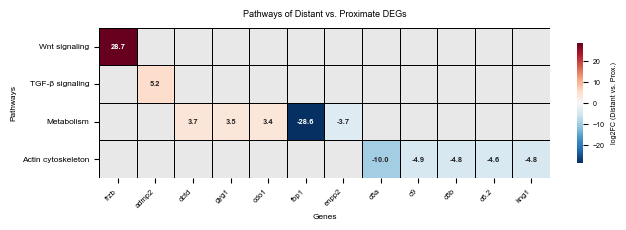

In [68]:
to_draw_pathways=['path:xla04310','path:xla04350','path:xla01100','path:xla04810']
to_draw_genes=['frzb','admp2','dctd','gyg1','cdo1','fbp1','enpp2','c8a','c9','c8b','c6.2','kng1']

gene_log2fc_value_dict={}
for i in range(len(to_analyse_expression_adata.uns['rank_genes_groups']['names'])):
    Uns=to_analyse_expression_adata.uns['rank_genes_groups']
    c_gene=Uns['names'][i][0]
    if c_gene in to_draw_genes:
        gene_log2fc_value_dict[c_gene]=Uns['logfoldchanges'][i][0]

fig,ax=draw_gene_pathway_map(to_draw_pathways,to_draw_genes,pathway_gene_dict,pathway_id_to_brief_name_dict,gene_log2fc_value_dict)
plt.savefig('./save_drawing/subcenter_related/gene_pathway_association_map.pdf',bbox_inches=None)
plt.show()